In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import pickle

sys.path.append(os.path.abspath("../analysis_tools/"))
from utils import * 

# load first few rows from parquet
import fastparquet
from pycytominer import feature_select

# for median absolute deviation
import scipy.stats as ss

# for Louvain clustering
import community as community_louvain
import networkx as nx
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
import scipy.spatial as spt
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# make cell crops
import skimage.io

# for legends heatmap annotations
from matplotlib.patches import Patch, RegularPolygon, Polygon
import matplotlib.lines as mlines

# upset plots
from upsetplot import generate_counts, plot

from upsetplot import UpSet


In [2]:
# Define one way to color variants, use when highlighting specific variants
variant_type_palette = \
    {
        'Missense':'grey',
        'Synonymous':'green',
        'WT':'grey', 
        'Frameshift':'purple', 
        '3nt Deletion':'grey', 
        'Nonsense':'purple', 
        'Other':'grey'
    }

# Define mutational types in dataset
mutation_types = ['Missense','Synonymous','Frameshift']


In [ ]:
# Make directory to put plots in
!mkdir consensus_plots_postreview

In [4]:
# Import profiles
# R1
# Save profiles
df_profiles_R1 = \
    pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Replicate1/R1_variant_profiles_medianplusEMD_selected_nopunctaline_010425.csv')
df_profiles_R1.drop(columns='Unnamed: 0',inplace=True)

feat_selected_R1 = [s for s in df_profiles_R1.columns\
                                if s not in ['Variant',
                                             'Variant_Class',
                                             'Metadata_Object_Count',
                                             'UMAP1',
                                             'UMAP2']
                   ]
var_R1 = df_profiles_R1.Variant
df_profiles_R1.drop(columns='Variant',inplace=True)
df_profiles_R1.index = var_R1

# R2
df_profiles_R2 = \
    pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Replicate2/R2_variant_profiles_medianplusEMD_selected_nopunctaline_010425.csv')
df_profiles_R2.drop(columns='Unnamed: 0',inplace=True)
#df_profiles_R2 = pd.read_parquet('../outputs/LMNAT3R2_v2/LMNAT3R2_v2_selected.parquet')

feat_selected_R2 = [s for s in df_profiles_R2.columns\
                                if s not in ['Variant',
                                             'Variant_Class',
                                             'Metadata_Object_Count',
                                             'UMAP1',
                                             'UMAP2']
                   ]
var_R2 = df_profiles_R2.Variant
df_profiles_R2.drop(columns='Variant',inplace=True)
df_profiles_R2.index = var_R2

# merge by taking average
var_common = list(set(var_R1).intersection(set(var_R2)))
feat_common = list(set(feat_selected_R1).intersection(set(feat_selected_R2)))
df_profiles_merged = \
    (df_profiles_R1.loc[var_common,feat_common] + df_profiles_R2.loc[var_common,feat_common])/2 #Average profiles
df_profiles_merged['NCells_R1'] = df_profiles_R1.loc[var_common,'Metadata_Object_Count']
df_profiles_merged['NCells_R2'] = df_profiles_R2.loc[var_common,'Metadata_Object_Count']
df_profiles_merged.reset_index(inplace=True)
df_profiles_merged['Variant_Class'] = \
    pd.Categorical(df_profiles_merged['Variant'].astype(str).apply(variant_classification),
                       categories=mutation_types, ordered=True)


In [5]:
# Plot correlation between impact scores for replicates
df_profiles_R1_synmedian = \
    df_profiles_R1\
        .query('Variant_Class == "Synonymous"')\
        [feat_common].agg(np.median)
variant_cosine_similarity_R1 = \
    cosine_similarity(df_profiles_R1[feat_common], df_profiles_R1_synmedian.values.reshape(1,-1))
df_profiles_R1['Morphological Impact Score'] = \
    (1-variant_cosine_similarity_R1[:,0])/2
df_profiles_R1['Variant_Class'] = \
        pd.Categorical(df_profiles_R1['Variant_Class'].map(lambda x: 'Missense' if x=='Single Missense' else x),
                       categories=mutation_types, ordered=True)

df_profiles_R2_synmedian = \
    df_profiles_R2\
        .query('Variant_Class == "Synonymous"')\
        [feat_common].agg(np.median)
variant_cosine_similarity_R2 = \
    cosine_similarity(df_profiles_R2[feat_common], df_profiles_R2_synmedian.values.reshape(1,-1))
df_profiles_R2['Morphological Impact Score'] = \
    (1-variant_cosine_similarity_R2[:,0])/2
df_profiles_R2['Variant_Class'] = \
        pd.Categorical(df_profiles_R2['Variant_Class'].map(lambda x: 'Missense' if x=='Single Missense' else x),
                       categories=mutation_types, ordered=True)

# Compute correlation plot between morphological impact scores
# Compute linear regression parameters
r1_mis = df_profiles_R1.loc[var_common,'Morphological Impact Score']
r2_mis = df_profiles_R2.loc[var_common,'Morphological Impact Score']

slope, intercept, r_value, p_value, std_err = ss.linregress(r1_mis,r2_mis)

# Prepare line values for the best-fit line
line_x = np.linspace(r1_mis.min(), r1_mis.max(), 100)
line_y = slope * line_x + intercept

# Plot
plot_df = pd.DataFrame({
    "r1": r1_mis,
    "r2": r2_mis,
    "Variant_Class": df_profiles_R1.loc[var_common, "Variant_Class"]
})
plot_df = plot_df.sort_values("Variant_Class")
fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(data=plot_df,
                x='r1', 
                y='r2', 
                hue='Variant_Class',
                palette=variant_type_palette,
                ax=ax,
                legend=False)
#ax.plot(line_x, line_y, color='red')

# Add labels
ax.set_xlabel('Impact Score Replicate 1', fontsize=14)
ax.set_ylabel('Impact Score Replicate 2', fontsize=14)

# Display R^2 on the plot
ax.text(
    0.05, 0.9, 
    f'$R = {r_value:.2f}$', 
    transform=ax.transAxes, 
    fontsize=20, 
    bbox=dict(facecolor='white', alpha=0.5)
)

# Show legend and plot
#ax.legend(loc='lower right', markerscale=2)
plt.tight_layout()
fig.savefig('./consensus_plots_postreview/LMNAT3.morphologicalimpactscore.correlationbetweenreps.011325.pdf')
plt.close()


In [6]:
# Plot correlation between NCells for replicates
# Compute correlation plot 
# Compute linear regression parameters
r1_ncells = df_profiles_merged['NCells_R1']
r2_ncells = df_profiles_merged['NCells_R2']

slope, intercept, r_value, p_value, std_err = ss.linregress(r1_ncells, r2_ncells)

# Prepare line values for the best-fit line
line_x = np.linspace(r1_ncells.min(), r1_ncells.max(), 100)
line_y = slope * line_x + intercept

# Plot
plot_df = pd.DataFrame({
    "r1": r1_ncells,
    "r2": r2_ncells,
    "Variant_Class": df_profiles_merged["Variant_Class"]
}).sort_values("Variant_Class")  # add ascending=False if you want later classes on top
fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(data=plot_df,
                x="r1",
                y="r2",
                hue="Variant_Class",
                palette=variant_type_palette,
                ax=ax)
#ax.plot(line_x, line_y, color='red', label='Best Fit Line')

# Add labels
ax.set_xlabel('Number of Cells per Variant Replicate 1', fontsize=14)
ax.set_ylabel('Number of Cells per Variant Replicate 2', fontsize=14)

# Display R^2 on the plot
ax.text(
    0.05, 0.9, 
    f'$R = {r_value:.2f}$', 
    transform=ax.transAxes, 
    fontsize=20, 
    bbox=dict(facecolor='white', alpha=0.5)
)

# Show legend and plot
ax.legend(loc='lower right', markerscale=2, title='Variant Type', title_fontsize=14, fontsize=12)
ax.set_xlim(100,10000)
ax.set_ylim(100,10000)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
fig.savefig('./consensus_plots_postreview/LMNAT3.ncellspervariant.correlationbetweenreps.011325.pdf')
plt.close()



In [7]:
# Perform PCA to get fraction variance explained plot
n_comp_pca_test=50
pca = PCA(n_components=n_comp_pca_test)
variant_medianplusemd_scaled = df_profiles_merged[feat_common].values
variant_medianplusemd_pca = pca.fit_transform(variant_medianplusemd_scaled)

# Plot fraction variance explained
plt.plot(list(range(n_comp_pca_test)), pca.explained_variance_ratio_)
plt.title('Fraction variance explained by PC')

# choose number of PCA dim to explain >80% of variance
var_explained_thresh = 0.80
pca_var_explained = np.asarray([np.sum(pca.explained_variance_ratio_[:i]) for i in range(n_comp_pca_test)])
n_comp_pca=sum(pca_var_explained <= var_explained_thresh)
plt.axvline(x=n_comp_pca, c='r')
plt.close()

# perform PCA again
print('PCA dimensions: ' + str(n_comp_pca))
pca = PCA(n_components=n_comp_pca)
variant_medianplusemd_pca = pca.fit_transform(variant_medianplusemd_scaled)
df_variant_medianplusEMD_features_pca = \
    pd.DataFrame(data = variant_medianplusemd_pca, 
                 columns=['PC'+str(i+1) for i in range(n_comp_pca)])
df_variant_medianplusEMD_features_pca['Variant'] = df_profiles_merged['Variant']
df_variant_medianplusEMD_features_pca['Variant_Class'] = df_profiles_merged['Variant_Class']


PCA dimensions: 12


In [ ]:
# Perform UMAP of median and EMD values
umap_model = umap.UMAP(n_neighbors=5, 
                       random_state=42, 
                       metric='cosine', 
                       n_components=2)
umap_embedding_means = umap_model.fit_transform(variant_medianplusemd_pca)

# Plot umap on EMD values
df_profiles_merged['UMAP1'] = umap_embedding_means[:,0]
df_profiles_merged['UMAP2'] = umap_embedding_means[:,1]

# Save df_profiles_merged


In [8]:
# Read merged profiles
df_profiles_merged = pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Merged/LMNA_averaged_medianplusEMD_010425.csv', index_col=None)
df_profiles_merged.drop(columns='Unnamed: 0',inplace=True)
df_profiles_merged['Variant_Class'] = \
     pd.Categorical(df_profiles_merged['Variant'].astype(str).apply(variant_classification),
                    categories=mutation_types, ordered=True)
features_common = [c for c in df_profiles_merged.columns if c not in ['Variant','Variant_Class',
                                                                      'NCells_R1','NCells_R2',
                                                                      'UMAP1','UMAP2',
                                                                      'Louvain Cluster']]


In [9]:
# Plot number of cells for each type of variant
df_profiles_toplot = df_profiles_merged.copy()
df_profiles_toplot['NCells_Tot'] = df_profiles_merged['NCells_R1']+df_profiles_merged['NCells_R2']
df_profiles_toplot['Variant Type'] = \
    pd.Categorical(df_profiles_merged['Variant_Class'].map({'Synonymous':'Synon',
                                                            'Missense':'Missense',
                                                            'Frameshift':'Frame-\nshift'}), 
                   categories=['Synon','Missense','Frame-\nshift'], ordered=True)
fig,ax=plt.subplots(figsize=(3.5,4))
boxplot_with_significance(
    df_profiles_toplot,
    x_col="Variant Type",
    y_col="NCells_Tot",
    hue_col=None,
    order=['Synon','Missense','Frame-\nshift'],
    palette={'Synon':'darkgreen',
             'Missense':'grey',
             'Frame-\nshift':'purple'},
    alpha=0.001,
    pairs=None,            # list of (group1, group2) pairs to compare
    shared_label="***",    # text to show if any comparison is p < alpha
    offset=0.02,
    show_points=True,
    anno_sample_sizes=True,
    ax=ax
)
ax.set_yscale('log')
ax.set_xlabel("")
ax.set_ylabel('Profiled cells per variant', fontsize=14)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.close()
fig.savefig('./consensus_plots_postreview/ntotalcells.LMNA.052725.pdf', dpi=600)


In [10]:
# Plot grey Single Missense points first (in the back) with lower alpha
# Split the data into grey points and other points
subset_grey = df_profiles_merged[df_profiles_merged['Variant_Class'] == 'Missense']
subset_color = df_profiles_merged[df_profiles_merged['Variant_Class'] != 'Missense']

# Create the figure and axis
fig, ax = plt.subplots(figsize=(4, 4))

sns.scatterplot(data=subset_grey, 
                x='UMAP1', 
                y='UMAP2', 
                color='grey', 
                s=40, 
                alpha=0.3,
                ax=ax)

# Plot the colored points on top
sns.scatterplot(data=subset_color, 
                x='UMAP1', 
                y='UMAP2', 
                hue='Variant_Class',
                palette={'Synonymous': 'green',
                         'Missense': 'grey',
                         'Frameshift': 'purple'},
                s=40,
                ax=ax)

# Create custom legend entries
synonymous_legend = mlines.Line2D([], [], color='green', marker='o', linestyle='',
                                  markersize=6, label='Synon')
single_missense_legend = mlines.Line2D([], [], color='grey', marker='o', linestyle='',
                                       markersize=6, alpha=0.3, label='Missense')
frameshift_legend = mlines.Line2D([], [], color='purple', marker='o', linestyle='',
                                  markersize=6, label='Frameshift')

# Add the custom legend
ax.legend(handles=[synonymous_legend, single_missense_legend, frameshift_legend],
          markerscale=1.2,
          title='Variant Type',
          loc='upper right',
          fontsize=10,
          title_fontsize=12)

# Remove x-axis and y-axis tick labels and ticks
plt.xticks([])
plt.yticks([])

# Label axes
plt.xlabel('UMAP 1', fontsize=16)
plt.ylabel('UMAP 2', fontsize=16)
plt.tight_layout()

# Save the figure
fig.savefig('./consensus_plots_postreview/LMNAT3.UMAP.011025.pdf', dpi=600)
plt.close()


In [14]:
# Perform Louvain clustering
labels,nclust = \
    cluster_louvain(
        df_profiles_merged[['Variant','UMAP1','UMAP2']]\
            .merge(df_variant_medianplusEMD_features_pca, on='Variant', how='left')\
            [['PC'+str(i+1) for i in range(n_comp_pca)]], # making sure that the variant ordering is still the same!
        k=25,
        metric='cosine',
        weighted=False
    )
df_profiles_merged['Louvain Cluster'] = labels

# Save df_profiles_merged


In [11]:
# Read profiles
df_profiles_merged = pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Merged/LMNA_averaged_medianplusEMD_010425.csv', index_col=None)
df_profiles_merged.drop(columns='Unnamed: 0',inplace=True)
df_profiles_merged['Variant_Class'] = \
     pd.Categorical(df_profiles_merged['Variant'].astype(str).apply(variant_classification),
                    categories=mutation_types, ordered=True)
features_common = [c for c in df_profiles_merged.columns if c not in ['Variant','Variant_Class',
                                                                      'NCells_R1','NCells_R2',
                                                                      'UMAP1','UMAP2',
                                                                      'Louvain Cluster',
                                                                      'Morphological Impact Score']]

# Rename clusters
cluster_remap = \
    {
        0: 8,
        1: 9,
        2: 2,
        3: 10,
        4: 3,
        5: 4,
        6: 6,
        7: 7,
        8: 5,
        9: 1
    }
nclust=len(cluster_remap.keys())
df_profiles_merged['Cluster'] = \
    df_profiles_merged['Louvain Cluster'].map(lambda x: cluster_remap[x])


In [12]:
# Define phenotyping impact scores
df_profiles_synmedian = \
    df_profiles_merged\
        .query('Variant_Class == "Synonymous"')\
        [features_common].agg(np.median)

# compute cosine similarity to median synonymous profile
variant_cosine_similarity = \
    cosine_similarity(df_profiles_merged[features_common], df_profiles_synmedian.values.reshape(1,-1))
df_profiles_merged['Morphological Impact Score'] = \
    (1-variant_cosine_similarity[:,0])/2


In [13]:
# Visualize Louvain Clusters
# Look at UMAP clusters
fig,ax=plt.subplots(figsize=(5,4))
sns.scatterplot(data=df_profiles_merged, 
                x='UMAP1', 
                y='UMAP2', 
                hue='Cluster', 
                s=25, 
                palette={(i+1):sns.color_palette()[i] for i in range(nclust)},
                legend=True,
                ax=ax)

plt.legend(markerscale=3, 
           bbox_to_anchor=(1.02,1), 
           fontsize=14,
           title_fontsize=16)

# Remove x-axis tick labels and ticks
plt.xticks([])

# Remove y-axis tick labels and ticks
plt.yticks([])

# Set labels
plt.xlabel('UMAP 1', fontsize=16)
plt.ylabel('UMAP 2', fontsize=16)

#plt.tight_layout()
plt.tight_layout()
fig.savefig('./consensus_plots_postreview/LMNAT3.UMAP.LouvainCluster.v2.021325.pdf', dpi=600)
plt.close()


In [ ]:
# Compute stability and cleanliness of clusters
def cluster_fn_wrapper(X_run, k, metric, weighted, resolution):
    return cluster_louvain(
        X_run, k=k, metric=metric, weighted=weighted, resolution=resolution
    )

# PCA
df_variant_medianplusEMD_features_pca = pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Merged/LMNA_averaged_medianplusEMD_PCA_021325.csv', index_col=0)
n_comp_pca=12

stability = run_louvain_stability(
    df_profiles_merged[['Variant','UMAP1','UMAP2']]\
        .merge(df_variant_medianplusEMD_features_pca, on='Variant', how='left')\
        [['PC'+str(i+1) for i in range(n_comp_pca)]], # making sure that the variant ordering is still the same!
    cluster_fn=cluster_fn_wrapper,
    n_runs=100,
    k=25,
    metric="cosine",
    weighted=False,
    resolution=1.0,
    random_subsample_frac=0.9,      # drop out between 5-20% of cells for each run
    pca_dim_dropout_frac=0.0,       # don't drop out PCA dim for now
    seed=1,
    build_consensus=True,
    return_all_labels=True,
)


In [ ]:
# Import Gwen's ROC AUC
roc_auc_lmna = pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/AUROC/results/train_results.csv')
roc_auc_lmna = roc_auc_lmna[['aaChanges','test_roc_auc']].rename(columns={'aaChanges':'Variant','test_roc_auc':'AUC ROC'})


In [14]:
# Load aggregated feature medians / EMDs for both replicates, zscore and average them
median_df_r2 = \
    pd.read_parquet('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Replicate2/LMNAT3R2.cellprofiler_122824.median.cellaggregated.parquet')
median_df_r1 = \
    pd.read_parquet('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Replicate1/LMNAT3R1.cellprofiler_122824.median.cellaggregated.parquet')

EMD_df_r2 = \
    pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Replicate2/LMNA_T3R2.bycell.full_EMD.csv')
EMD_df_r1 = \
    pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Replicate1/LMNA_T3R1.bycell.full_EMD.csv')


In [30]:
# Compute average of median features
variant_medians_merged = \
    prepare_consensus_variant_scores([median_df_r1,median_df_r2])
variant_medians_merged['Variant_Class'] = \
    pd.Categorical(
        variant_medians_merged['Variant'].astype(str).apply(variant_classification),
            categories=mutation_types, 
            ordered=True)
#variant_medians_merged.to_csv('./consensus_profiles/LMNA_merged_featuremedians_010625.csv')

# Compute average of EMD features
variant_EMD_merged = \
    prepare_consensus_variant_scores([EMD_df_r1,EMD_df_r2], variant_col="Variant")
variant_EMD_merged['Variant_Class'] = \
    pd.Categorical(
        variant_EMD_merged['Variant'].astype(str).apply(variant_classification),
            categories=mutation_types, 
            ordered=True)
#variant_EMD_merged.to_csv('./consensus_profiles/LMNA_merged_featureEMD_010925.csv')


In [ ]:
# import medians and EMD merged
variant_medians_merged = pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Merged/LMNA_merged_featuremedians_010625.csv')
variant_medians_merged.drop(columns='Unnamed: 0', inplace=True)
variant_EMD_merged = pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Merged/LMNA_merged_featureEMD_010925.csv')
variant_EMD_merged.drop(columns='Unnamed: 0', inplace=True)


In [32]:
# Set landmark features
landmark_features = \
    {
        'Mean_NucleiExpanded_Intensity_MeanIntensity_CH1'   : 'Lamin A Nuc\nIntensity',
        'Mean_NuclearBoundary_Intensity_MeanIntensity_CH1'  : 'Lamin A Nuc\nBndry Intensity',
        'Mean_NucleiExpanded_Granularity_1_CH1'             : 'Lamin A Nuc\nGranularity 1',
        'Mean_Nuclei_AreaShape_FormFactor'                  : 'Nuc Circularity'
    }
total_landmark_features = \
    [c+'_median' for c in landmark_features.keys()] + \
    [c+'_EMD' for c in landmark_features.keys()]


In [15]:
# Compute correlation plot between LMNA intensity
median_df_r1_forcorr = median_df_r1.copy()
median_df_r1_forcorr.index = median_df_r1_forcorr['aaChanges']
median_df_r2_forcorr = median_df_r2.copy()
median_df_r2_forcorr.index = median_df_r2_forcorr['aaChanges']

r1_meanintensity = median_df_r1_forcorr.loc[var_common,'Mean_NucleiExpanded_Intensity_MeanIntensity_CH1']
r2_meanintensity = median_df_r2_forcorr.loc[var_common,'Mean_NucleiExpanded_Intensity_MeanIntensity_CH1']

slope, intercept, r_value, p_value, std_err = ss.linregress(r1_meanintensity,r2_meanintensity)
r_squared = r_value**2

# Prepare line values for the best-fit line
line_x = np.linspace(r1_meanintensity.min(), r1_meanintensity.max(), 100)
line_y = slope * line_x + intercept

# Build plotting frame
df_profiles_merged_toplot = df_profiles_merged.copy()
df_profiles_merged_toplot.index = df_profiles_merged_toplot['Variant']
df_toplot = (
    pd.DataFrame({
        "r1": r1_meanintensity,
        "r2": r2_meanintensity,
        "Variant_Class": df_profiles_merged_toplot.loc[var_common,"Variant_Class"]
    })
    .sort_values("Variant_Class")  # ascending draws first; use ascending=False to flip
)

#Plot
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.scatterplot(
    data=df_toplot,
    x="r1",
    y="r2",
    hue="Variant_Class",
    palette=variant_type_palette,
    ax=ax,
    legend=False
)

# Optional best-fit line
# ax.plot(line_x, line_y, color='red')

ax.set_xlabel('LMNA Mean Nuclear Intensity Replicate 1', fontsize=14)
ax.set_ylabel('LMNA Mean Nuclear Intensity Replicate 2', fontsize=14)
ax.text(
    0.05, 0.9,
    f'$R = {r_value:.2f}$',
    transform=ax.transAxes,
    fontsize=20,
    bbox=dict(facecolor='white', alpha=0.5)
)
ax.set_xlim(0.01, 0.018)
ax.set_ylim(0.0085, 0.015)
plt.tight_layout()
fig.savefig('./consensus_plots_postreview/LMNAT3.MeanNucIntensity.correlationbetweenreps.011325.pdf')
plt.close()


In [ ]:
# import KS statistics
variant_feature_pvalues_rep1_df = pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Replicate1/LMNA_T3R1.bycell.full_p_values.csv')
variant_feature_pvalues_rep1_df.index = variant_feature_pvalues_rep1_df['Variant']
variant_feature_pvalues_rep1_df = variant_feature_pvalues_rep1_df.drop('Variant', axis=1)

variant_feature_pvalues_rep2_df = pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Replicate2/LMNA_T3R2.bycell.full_p_values.csv')
variant_feature_pvalues_rep2_df.index = variant_feature_pvalues_rep2_df['Variant']
variant_feature_pvalues_rep2_df = variant_feature_pvalues_rep2_df.drop('Variant', axis=1)


In [ ]:
# perform meta analysis to combine p-values
df_KSpvalues_merged = pd.DataFrame(index=df_profiles_merged['Variant'],
                                   columns=variant_feature_pvalues_rep1_df.columns)
for v in df_profiles_merged['Variant']:
    for f in variant_feature_pvalues_rep1_df.columns:
        df_KSpvalues_merged.loc[v,f] = \
            ss.combine_pvalues([variant_feature_pvalues_rep1_df.loc[v,f], 
                                variant_feature_pvalues_rep2_df.loc[v,f]],
                               method='fisher'
                              )[1]
                       


KeyboardInterrupt



In [ ]:
# Save meta-analysis merged p-values
#df_KSpvalues_merged.to_csv('./consensus_profiles/LMNA_merged_KSpvalues_010924.csv')


In [17]:
# Load meta-analysis merged p-values
df_KSpvalues_merged = \
    pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Merged/LMNA_merged_KSpvalues_010924.csv')
blocked_features = [s for s in df_KSpvalues_merged.columns if 'Puncta' in s or 'Line' in s]
df_KSpvalues_merged.index = df_KSpvalues_merged['Variant']
df_KSpvalues_merged.drop(columns=['Variant']+blocked_features, inplace=True)
nonblocked_features = df_KSpvalues_merged.columns


In [16]:
# Look at reproducibility plot of EMD - reps 1 and 2
# remove non-reproducible features
df_WTemd_rep2 = pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Replicate2/LMNAT3R2_WT_EMDreplicates.csv')
df_WTemd_rep2.drop(columns='Unnamed: 0',inplace=True)
df_WTemd_rep1 = pd.read_csv('../VISseq_summarydata_v0.2/LMNA_VIS-seq/Replicate1/LMNAT3R1_WT_EMDreplicates.csv')
df_WTemd_rep1.drop(columns='Unnamed: 0',inplace=True)

# Plot and filter by replicate separately
df_WTemd_rep1_avg = df_WTemd_rep1.mean(axis=0)
df_WTemd_rep1_avg_sorted = df_WTemd_rep1_avg.sort_values(ascending=True)
emd_score_WT_Q3_rep1 = np.percentile(df_WTemd_rep1_avg_sorted,75)
emd_score_WT_Q1_rep1 = np.percentile(df_WTemd_rep1_avg_sorted,25)
emd_score_WT_IQR_rep1 = emd_score_WT_Q3_rep1 - emd_score_WT_Q1_rep1
emd_score_WT_thresh_rep1 = 1.5*emd_score_WT_IQR_rep1 + emd_score_WT_Q1_rep1 # 1.5 x IQR plus Q1

df_WTemd_rep2_avg = df_WTemd_rep2.mean(axis=0)
df_WTemd_rep2_avg_sorted = df_WTemd_rep2_avg.sort_values(ascending=True)
emd_score_WT_Q3_rep2 = np.percentile(df_WTemd_rep2_avg_sorted,75)
emd_score_WT_Q1_rep2 = np.percentile(df_WTemd_rep2_avg_sorted,25)
emd_score_WT_IQR_rep2 = emd_score_WT_Q3_rep2 - emd_score_WT_Q1_rep2
emd_score_WT_thresh_rep2 = 1.5*emd_score_WT_IQR_rep2 + emd_score_WT_Q1_rep2 # 1.5 x IQR plus Q1

fig,axs=plt.subplots(ncols=2, figsize=(10,5), sharey=True)
axs[0].scatter(list(range(1,len(df_WTemd_rep1_avg_sorted.index)+1)),
            df_WTemd_rep1_avg_sorted,
            s=1)
axs[0].axhline(y=emd_score_WT_thresh_rep1, color='r', linestyle='--')
axs[1].scatter(list(range(1,len(df_WTemd_rep2_avg_sorted.index)+1)),
            df_WTemd_rep2_avg_sorted,
            s=1)
axs[1].axhline(y=emd_score_WT_thresh_rep2, color='r', linestyle='--')


axs[0].set_yscale('log')
axs[1].set_yscale('log')

axs[0].set_ylabel('EMD Average Score', fontsize=16)

axs[0].set_xlabel('Feature Rank', fontsize=16)
axs[1].set_xlabel('Feature Rank', fontsize=16)

axs[0].set_title('Rep 1 LMNA', fontsize=18)
axs[1].set_title('Rep 2 LMNA', fontsize=18)

axs[0].tick_params(axis='both',labelsize=14)
axs[1].tick_params(axis='both',labelsize=14)

plt.close()
fig.savefig('./consensus_plots_postreview/EMD_reproducibility_byreplicate_011324.pdf', dpi=600)

features_reproducible = \
    (df_WTemd_rep1_avg<=emd_score_WT_thresh_rep1) & (df_WTemd_rep2_avg<=emd_score_WT_thresh_rep2)
features_reproducible = features_reproducible.index[features_reproducible]


In [18]:
# Make plot of number of significant features using p-values computed on _CELLS_ aggregated data, using KS test
# Filter for reproducible features
# Remove puncta/line features
features_reproducible_filtered = \
    [f for f in features_reproducible if ('Puncta' not in f) & ('Line' not in f)]

df_KSpvalues_merged_filt = \
    df_KSpvalues_merged[features_reproducible_filtered]

# Set Bonferroni FDR at q<=10^-3
p_value_thresh = 0.001/(np.prod(df_KSpvalues_merged_filt.shape)) # BONFERRONI FDR

variant_bycell_numsigfeatures = \
    (df_KSpvalues_merged_filt <= p_value_thresh).sum(axis=1).reset_index()
variant_bycell_numsigfeatures = \
    variant_bycell_numsigfeatures[variant_bycell_numsigfeatures['Variant']!='sig_gene_count']
variant_bycell_numsigfeatures.rename({0:'Num Significant Features'}, axis=1, inplace=True)
variant_bycell_numsigfeatures['Variant_Class'] = \
    pd.Categorical(variant_bycell_numsigfeatures['Variant'].astype(str).apply(variant_classification),
                   categories=['Missense','Frameshift','Synonymous'], ordered=True)

#fig,ax=plt.subplots(figsize=(8,6))
num_sig_features_plot = \
    sns.displot(data=variant_bycell_numsigfeatures,
                 x="Num Significant Features", 
                 hue="Variant_Class",
                 kind='kde',
                 palette=variant_type_palette,
                 legend=True,
                 common_norm=False)
plt.ylabel('Density', fontsize=14)
plt.xlabel('# Significant Features', fontsize=14)
plt.tick_params(axis='both',labelsize=12)

# Access the legend object from the FacetGrid
legend = num_sig_features_plot._legend

# Change the legend title font size
legend.set_title("Variant Type", prop={'size': 14})

# Change the legend labels font size
plt.setp(legend.get_texts(), fontsize=12)

num_sig_features_plot.savefig('./consensus_plots_postreview/KStest_numsigfeatures_byvariantclass_011324.pdf')
plt.close()


In [19]:
# What are the variants with the most differential features?
variant_bycell_numsigfeatures\
    .sort_values(by='Num Significant Features', ascending=False)[0:10]


,Variant,Num Significant Features,Variant_Class
107,D272W,614,Missense
827,D185P,579,Missense
246,Y267S,577,Missense
108,Y267R,573,Missense
1216,K260C,552,Missense
1682,R196W,551,Missense
1229,K201P,536,Missense
837,Q198W,529,Missense
1368,Y267D,526,Missense
1237,M187Q,523,Missense


In [39]:
# Function to classify features from various compartments
# Define autopct function to hide labels below 1%
def autopct_hide_small(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''

# Classify the features with dyes
channel_to_dye_dict = {
    'CH0': 'DAPI',
    'CH1': 'mEGFP-\nLaminA',
    'CH2': 'Phalloidin\n+WGA',
    'CH3': 'Mitoprobe'
}
classified_features = \
    classify_features_with_dye(nonblocked_features, channel_to_dye=channel_to_dye_dict)

# Convert results to DataFrame and display
feature_df = pd.DataFrame(classified_features)
feature_df['Imaging Channel'] = \
    feature_df['associated_dye'].map(lambda x: 'Multiple' if ',' in x else 'None' if x=='' else x)

# Count the occurrences of each compartment
channel_counts = feature_df['Imaging Channel'].value_counts()
channel_palette = {
    'DAPI': 'darkblue',
    'mEGFP-\nLaminA': 'lime',
    'Phalloidin\n+WGA': 'darkorange',
    'Mitoprobe': 'darkred',
    'None': 'grey',
    'Multiple': 'purple',
}


In [40]:
# Function to classify features from various compartments
# Classify the features with dyes
classified_features = \
    classify_compartment(nonblocked_features)

# Convert results to DataFrame and display
feature_df['Compartment'] = classified_features

# Count the occurrences of each compartment
compartment_counts = feature_df['Compartment'].value_counts()

# Set palette
compartment_palette = {
    'Whole Cell' : 'mediumpurple',
    'Nuclei'     : 'darkcyan', 
    'Cytoplasm'  : 'peachpuff'
}


In [41]:
# Function to classify features computed via various methods
classified_features = \
    classify_method(nonblocked_features)

# Convert results to DataFrame and display
feature_df['Method'] = classified_features

# Count the occurrences of each compartment
method_counts = feature_df['Method'].value_counts()

# Set index
feature_df.index = feature_df['feature']

# Set palette
methods = ["AreaShape", "Intensity", "RadialDistribution", "Correlation", "Granularity", "Texture", "Neighbors", "Count"]
method_palette = {m:sns.color_palette("Set2")[i] for i,m in enumerate(methods)}


In [50]:
# Function to classify features computed from various methods
feature_df.to_csv('./consensus_plots_postreview/feature_df.csv')


In [42]:
# Make a volcano plot
# p-value vs median/EMD
# Set indices correctly for medians and EMD matrices
variant_medians_merged_toplot = variant_medians_merged.loc[:,nonblocked_features].copy()
variant_medians_merged_toplot.index = variant_medians_merged['Variant']
variant_EMD_merged_toplot = variant_EMD_merged.loc[:,features_reproducible_filtered].copy()
variant_EMD_merged_toplot.index = variant_EMD_merged['Variant']

# Set thresholds
effect_threshold = 0.25
size_range=(5,25)
size_counts_range=(0,1000)
size_legend_values=[0,500,1000]
p_value_thresh_geomean_median = 10**(-2)/len(nonblocked_features)
p_value_thresh_geomean_EMD    = 10**(-2)/len(features_reproducible_filtered)

# Create 2x2 subplots
fig, axs = plt.subplots(figsize=(9,10), nrows=2, ncols=2, sharey=True)

#Median
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_merged,
    variant_medians=variant_medians_merged_toplot,  # median matrix
    effect_label="Median feature z-score across variants",
    one_sided=False,
    p_threshold=p_value_thresh_geomean_median,      # also drives size scaling
    effect_threshold=effect_threshold,              # vertical line at effect threshold
    feature_df=feature_df,                          # indexed by feature
    color_by="Imaging Channel",                     # or "Compartment"
    palette=channel_palette,                        # dict label -> color
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[0,0],
    show_color_legend=False,
    show_size_legend=False
)
ax.set_xlabel("Median feature z-score across variants", fontsize=11)
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_merged,
    variant_medians=variant_medians_merged_toplot,  # median matrix
    effect_label="Median feature z-score across variants",
    one_sided=False,
    p_threshold=p_value_thresh_geomean_median,
    effect_threshold=effect_threshold,
    feature_df=feature_df,
    color_by="Compartment",
    palette=compartment_palette,
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[1,0],
    show_color_legend=False,
    show_size_legend=False
)
ax.set_xlabel("Median feature z-score across variants", fontsize=11)
volcano_median_df = volcano_df.copy()

#EMD
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_merged_filt,
    effect_df=variant_EMD_merged_toplot,    # all-positive EMD matrix
    effect_label="Median feature EMD z-score across variants",
    y_label=None,
    one_sided=True,
    p_threshold=p_value_thresh_geomean_EMD,
    effect_threshold=effect_threshold,
    feature_df=feature_df,
    color_by="Imaging Channel",
    palette=channel_palette,
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[0,1]
)
ax.set_xlabel("Median feature EMD z-score across variants", fontsize=11)
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_merged_filt,
    effect_df=variant_EMD_merged_toplot,    # all-positive EMD matrix
    effect_label="Median feature EMD z-score across variants",
    y_label=None,
    one_sided=True,
    p_threshold=p_value_thresh_geomean_EMD,
    effect_threshold=effect_threshold,
    feature_df=feature_df,
    color_by="Compartment",
    palette=compartment_palette,
    size_require_effect_threshold=True,
    show_size_legend=False,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=landmark_features,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=axs[1,1]
)
ax.set_xlabel("Median feature EMD z-score across variants", fontsize=11)
volcano_EMD_df = volcano_df.copy()
plt.subplots_adjust(right=0.8)
fig.savefig('./consensus_plots_postreview/volcano_features_112825.pdf')
plt.close()

# Compute informative features by median and EMD
informative_features_bymedian = \
    volcano_median_df.query('geom_mean_p <= @p_value_thresh_geomean_median and abs(median_effect) >= @effect_threshold')['feature'].values
informative_features_byEMD = \
    volcano_EMD_df.query('geom_mean_p <= @p_value_thresh_geomean_EMD and median_effect >= @effect_threshold')['feature'].values

# Save dfs
volcano_total_df = \
    volcano_median_df\
        .rename(columns={c:c+'_median' for c in volcano_median_df.columns if c != "feature"})\
        .merge(volcano_EMD_df\
                .rename(columns={c:c+'_EMD' for c in volcano_EMD_df.columns if c != "feature"}), 
                on='feature', how='left')\
        .merge(feature_df.reset_index(drop=True)[['feature','Imaging Channel','Compartment', 'Method']], 
               on='feature', how='inner')
volcano_total_df['Imaging Channel'] = volcano_total_df['Imaging Channel'].str.replace("\n","")
volcano_total_df['Landmark'] = volcano_total_df['feature'].map(lambda x: True if x in landmark_features.keys() else False)
selected_median = [f.rstrip('_median') for f in features_common if not str(f).endswith("_EMD")]
selected_emd    = [f.rstrip('_EMD') for f in features_common if str(f).endswith("_EMD")]
volcano_total_df['Selected'] = volcano_total_df['feature'].map(lambda x: 'median+EMD' if (x in selected_median and x in selected_emd) \
                                                                            else 'median' if (x in selected_median) \
                                                                            else 'EMD' if (x in selected_emd) else False)
volcano_total_df['Hit'] = volcano_total_df['feature'].map(lambda x: True if x in informative_features_bymedian else False)
volcano_total_df.to_csv('./SuppTable1.csv', index=False)

# Create 2x2 subplots
fig, ax = plt.subplots(figsize=(4,5))

#Median
ax, volcano_df = plot_feature_volcano(
    df_pvalues=df_KSpvalues_merged,
    variant_medians=variant_medians_merged_toplot,  # median matrix
    effect_label="Median feature z-score across variants",
    one_sided=False,
    p_threshold=p_value_thresh_geomean_median,      # also drives size scaling
    effect_threshold=effect_threshold,              # vertical line at effect threshold
    feature_df=feature_df,                          # indexed by feature
    color_by="Imaging Channel",                     # or "Compartment"
    palette=channel_palette,                        # dict label -> color
    size_require_effect_threshold=True,
    size_range=size_range,
    size_counts_range=size_counts_range,
    size_legend_values=size_legend_values,
    highlight=None,
    annotate_threshold_hits=False,
    plot_title=None,
    ax=ax,
    show_color_legend=False,
    show_size_legend=False
)
ax.set_xlabel("Median feature z-score across variants", fontsize=12)
plt.tight_layout()
fig.savefig('./consensus_plots_postreview/LMNAT3.volcano_median_channel.011426.pdf')
plt.close()


In [43]:
# Plot stacked bars of the features
# Set up feature sets to plot
# Split selected_features into median vs EMD
selected_median = [f for f in features_common if not str(f).endswith("_EMD")]
selected_emd    = [f for f in features_common if str(f).endswith("_EMD")]

feature_sets = {
    "All":      {"median": nonblocked_features,           "emd": features_reproducible_filtered},
    "Selected": {"median": selected_median,               "emd": selected_emd},
    "Hits":     {"median": informative_features_bymedian, "emd": informative_features_byEMD},
}

# Plot only totals for now
fig, ax = plot_feature_composition(
    feature_df=feature_df,
    feature_sets=feature_sets,
    channel_palette=channel_palette,
    compartment_palette=compartment_palette,
    method_palette=method_palette,
    savepath="./consensus_plots_postreview/LMNAT3.feature_composition_grouped_singleplot.011626.pdf",
    figsize=(6, 5),
    bar_w_pair=0.15,
    pair_dx=0.10*0.40,
    dim_gap=0.20,
    group_gap=0.05,
    title="",
    mode="proportion",
    show_legend=True,
    total_only=True,
    show_nfeatures="top",
    legend_position="bottom",
    swap_grouping=True,
    legend_x_anchors=(-0.01, 0.05, 0.38, 0.58),  # (style, channel, compartment, method)
)


In [44]:
# Subset: define interpretable set (edit this filter as needed)
intfeat = feature_df.copy()

# If you have a precomputed boolean or list, swap this out.
# Example: keep only these methods
keep_methods = \
[
    "AreaShape", 
    "Correlation", 
    "Intensity", 
    "RadialDistribution", 
    "Granularity"
]
keep_ch = \
[
    'None',
    'mEGFP-\nLaminA',
    'Multiple'
]

intfeat = intfeat[intfeat["Method"].isin(keep_methods)].copy()
intfeat = intfeat[intfeat["Imaging Channel"].isin(keep_ch)].copy()
intfeat["Radial Subtype"]  = [radial_subtype(s) for s in intfeat.index]
intfeat = intfeat[intfeat['Radial Subtype'].isin(['NA','MeanFrac',
                                                  #'FracAtD','RadialCV'
                                                 ])].copy()
intfeat["Correlation Subtype"]  = [correlation_subtype(s) for s in intfeat.index]
#intfeat = intfeat[intfeat['Correlation Subtype'].isin(['NA','Correlation','RWC'])].copy()
intfeat["Intensity Subtype"]  = [intensity_subtype(s) for s in intfeat.index]
intfeat = intfeat[intfeat['Intensity Subtype'].isin(['NA','Median','Mean','Std'])].copy()
intfeat = intfeat[intfeat['Compartment'].isin([
                                                #'Whole Cell',
                                                'Nuclei'
                                              ])].copy()

# Stabilize category order (optional)
intfeat["Method"]          = pd.Categorical(intfeat["Method"], categories=keep_methods, ordered=True)
intfeat["Imaging Channel"] = pd.Categorical(intfeat["Imaging Channel"], categories=[
                                                                                    "None",
                                                                                    "mEGFP-\nLaminA", 
                                                                                    "Multiple"
                                                                                   ], ordered=True)
intfeat["Compartment"]     = pd.Categorical(intfeat["Compartment"], categories=[
                                                                                #"Whole Cell", 
                                                                                "Nuclei"
                                                                               ], ordered=True)
#intfeat["Radial Subtype"]  = pd.Categorical(intfeat["Radial Subtype"], categories=["NA", "FracAtD", "MeanFrac", "RadialCV", "Other"], ordered=True)


Best k for medians: 24 silhouette: 0.33006272452438057
Best k for EMDs: 34 silhouette: 0.2574538584618628


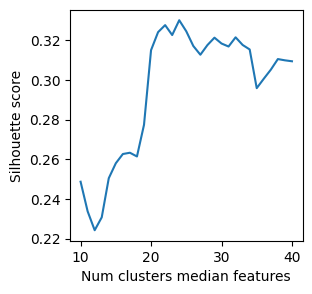

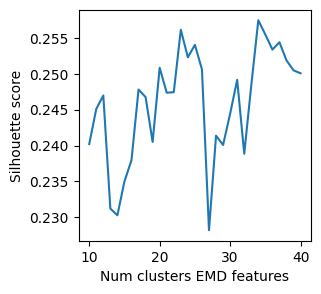

In [45]:
# Variant by features heatmaps, feature clustering, correlation heatmaps

# ----------------------------
# define helpers
# ----------------------------
def add_cluster_gaps(df, groups_ordered, gap_size=10):
    # groups_ordered is a sequence aligned to df rows
    rows = []
    new_groups = []
    prev = groups_ordered[0]
    for i, (idx, row) in enumerate(df.iterrows()):
        if i > 0 and groups_ordered[i] != prev:
            for _ in range(gap_size):
                rows.append(pd.Series([np.nan]*df.shape[1], index=df.columns))
                new_groups.append(np.nan)
        rows.append(row)
        new_groups.append(groups_ordered[i])
        prev = groups_ordered[i]
    df_gap = pd.DataFrame(rows).reset_index(drop=True)
    return df_gap, pd.Series(new_groups)

def compute_linkage_and_order(df_cols, metric="cosine", method="average"):
    """df_cols: DataFrame rows=variants (no gap rows), cols=features. Returns (Z, leaves)."""
    D = pairwise_distances(df_cols.T, metric=metric)
    np.fill_diagonal(D, 0.0)
    Z = hc.linkage(spt.distance.squareform(D, checks=False), method=method)
    leaves = hc.dendrogram(Z, no_plot=True)["leaves"]
    return Z, leaves

def highlight_columns_as_blocks(
    ax,
    ordered_cols,
    *,
    features=None,          # used when merge=True
    blocks=None,            # used when merge=False
    merge=True,
    block_mode="name",      # "name" or "index" (only relevant when blocks is used)
    facecolor="none",
    edgecolor="black",
    linewidth=1.0,
    alpha=1.0,
    zorder=10,
):
    """
    Highlight columns on a heatmap axis.

    Two modes:
    ----------
    merge=True:
        Provide `features` (iterable of column names). The function will:
          - map to x indices in `ordered_cols`
          - merge contiguous indices into blocks
          - draw one rectangle per merged block

    merge=False:
        Provide `blocks` explicitly. The function will:
          - draw exactly those blocks (no merging)
        blocks can be:
          - block_mode="name": list of (start_colname, end_colname)
          - block_mode="index": list of (start_index, end_index)
        where start/end are INCLUSIVE.

    Notes:
    ------
    - Rectangles span the full heatmap height.
    - Columns not found are ignored (in merge=True mode).
    """

    ordered_cols = list(ordered_cols)
    n_cols = len(ordered_cols)
    col_to_x = {c: i for i, c in enumerate(ordered_cols)}

    # Heatmap y extent in data coords
    y0, y1 = ax.get_ylim()
    y_bottom = min(y0, y1)
    height = abs(y1 - y0)

    def draw_block(x_start, x_end):
        # clamp to visible range
        x_start = max(0, x_start)
        x_end   = min(n_cols - 1, x_end)
        if x_end < x_start:
            return
        rect = mpatches.Rectangle(
            (x_start - 0.5, y_bottom),
            (x_end - x_start + 1),
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
            zorder=zorder,
        )
        ax.add_patch(rect)

    # -------------------------
    # merge=True: features -> merged blocks
    # -------------------------
    if merge:
        if features is None:
            raise ValueError("merge=True requires `features` (list of column names).")

        xs = sorted(col_to_x[f] for f in features if f in col_to_x)
        if not xs:
            return []

        merged = []
        s = prev = xs[0]
        for x in xs[1:]:
            if x == prev + 1:
                prev = x
            else:
                merged.append((s, prev))
                s = prev = x
        merged.append((s, prev))

        for s, e in merged:
            draw_block(s, e)

        return merged

    # -------------------------
    # merge=False: user-specified blocks
    # -------------------------
    else:
        if blocks is None:
            raise ValueError("merge=False requires `blocks` (explicit ranges).")

        out_blocks = []
        for b0, b1 in blocks:
            if block_mode == "name":
                if b0 not in col_to_x or b1 not in col_to_x:
                    continue
                s, e = col_to_x[b0], col_to_x[b1]
            elif block_mode == "index":
                s, e = int(b0), int(b1)
            else:
                raise ValueError("block_mode must be 'name' or 'index'")

            # ensure s <= e
            if e < s:
                s, e = e, s

            draw_block(s, e)
            out_blocks.append((s, e))

        return out_blocks

def draw_top_annotation_strips(
    fig,
    x0, y0, w, *,
    strips,                 # list of (name, colors_list) in TOP->BOTTOM order
    height=0.015,
    spacing=0.004,
    box_pad=0.002,
    add_separator=False,
    sep_lw=0.4,
    sep_alpha=0.6,
):
    """
    Draw annotation color strips as separate axes so spacing looks identical across figures.

    Parameters
    ----------
    strips : list of (name, colors)
        colors is length n_cols list of matplotlib color specs.
        Provided in TOP->BOTTOM order (e.g., [("Compartment", comp), ("Channel", chan)]).
    Returns
    -------
    total_height_used : float
        Total vertical space consumed (figure coords), including spacing and padding.
    """
    current_top = y0 + box_pad
    total = box_pad

    for i, (name, colors) in enumerate(strips):
        rgb = np.array([mcolors.to_rgb(c) for c in colors]).reshape(1, -1, 3)
        ax = fig.add_axes([x0, current_top, w, height])
        ax.imshow(rgb, aspect="auto", interpolation="nearest")
        ax.axis("off")

        # optional separator line UNDER this strip
        if add_separator and i < len(strips) - 1:
            y_sep = current_top - spacing/2
            fig.lines.append(mlines.Line2D(
                [x0, x0 + w],
                [y_sep, y_sep],
                transform=fig.transFigure,
                lw=sep_lw,
                alpha=sep_alpha,
                color="black",
            ))

        current_top += height + spacing
        total += height + spacing

    return total

def annotate_features_on_heatmap_axis(
    fig,
    ax_hm,
    ordered_cols,
    features_to_annotate,
    *,
    where="below",          # "below" or "above"
    side="right",           # "right" or "left"
    band_height=0.22,
    pad=0.006,
    fontsize=6,

    # --- where labels live in X ---
    label_mode="edge",      # "edge" | "inside_edge" | "relative"
    label_x_pad=0.9,        # edge mode
    inside_edge_pad=2.0,    # inside_edge mode
    label_dx_cols=6.0,      # relative mode
    clamp_to_heatmap=True,

    # --- line style ---
    tick_len_fig=0.004,
    line_lw=0.7,
    line_alpha=0.95,
    color="black",

    # --- spacing ---
    slots=None,
    y_top=0.92,
    y_bot=0.08,

    # --- ordering ---
    sort_by_x=True,         # for edge/inside_edge (or default)
    relative_fanout=True,   # NEW: in relative mode, assign y by label-anchor x to reduce conflicts

    clear_previous=False,   # don't nuke fig.lines unless you want to
):
    """
    Draw tidy 90° connectors from heatmap columns to labels in a band axis.

    In label_mode="relative" with relative_fanout=True:
      - side="right": larger x_label_col gets higher y (shorter vertical)
      - side="left" : smaller x_label_col gets higher y (shorter vertical)

    Returns the label-band axis, or None.
    """

    ordered_cols = list(ordered_cols)
    col_to_x = {c: i for i, c in enumerate(ordered_cols)}
    n_cols = len(ordered_cols)

    # Keep only annotated features present in this panel (in displayed order)
    pairs = [(c, features_to_annotate[c]) for c in ordered_cols if c in features_to_annotate]
    if not pairs:
        return None

    # band axis
    hm_pos = ax_hm.get_position()
    if where == "below":
        band_y0 = hm_pos.y0 - pad - hm_pos.height * band_height
    elif where == "above":
        band_y0 = hm_pos.y1 + pad
    else:
        raise ValueError("where must be 'below' or 'above'")

    ax_band = fig.add_axes([hm_pos.x0, band_y0, hm_pos.width, hm_pos.height * band_height])
    ax_band.set_xlim(-0.5, n_cols - 0.5)
    ax_band.set_ylim(0, 1)
    ax_band.axis("off")

    invF = fig.transFigure.inverted()
    def to_fig(ax, x, y):
        return invF.transform(ax.transData.transform((x, y)))

    # Heatmap edge
    y_top_hm = ax_hm.get_ylim()[1]
    y_bot_hm = ax_hm.get_ylim()[0]
    y_edge = y_bot_hm if where == "below" else y_top_hm
    _, y_edge_fig = to_fig(ax_hm, 0, y_edge)

    # Optional clearing
    if clear_previous:
        fig.lines = []

    # Helper: compute label anchor x (column units) + ha
    def label_anchor_x(x_col):
        if label_mode == "edge":
            if side == "right":
                return (n_cols - 1) + label_x_pad, "left"
            else:
                return -0.5 - label_x_pad, "right"

        if label_mode == "inside_edge":
            if side == "right":
                return (n_cols - 1) - inside_edge_pad, "left"
            else:
                return -0.5 + inside_edge_pad, "right"

        if label_mode == "relative":
            if side == "right":
                return x_col + label_dx_cols, "left"
            else:
                return x_col - label_dx_cols, "right"

        raise ValueError("label_mode must be 'edge', 'inside_edge', or 'relative'")

    # Build enriched list with x_col and x_label_col so we can order properly
    enriched = []
    for colname, label in pairs:
        x_col = col_to_x[colname]
        x_label_col, ha = label_anchor_x(x_col)
        if clamp_to_heatmap:
            x_label_col = float(np.clip(x_label_col, -0.5, n_cols - 0.5))
        enriched.append((colname, label, x_col, x_label_col, ha))

    # Ordering
    if label_mode == "relative" and relative_fanout:
        # side="right": bigger x_label_col -> higher y
        # side="left" : smaller x_label_col -> higher y
        if side == "right":
            enriched.sort(key=lambda t: t[3], reverse=True)  # x_label_col desc
        else:
            enriched.sort(key=lambda t: t[3])               # x_label_col asc
    else:
        if sort_by_x:
            enriched.sort(key=lambda t: t[2])  # x_col asc

    m = len(enriched)
    if slots is None:
        slots = m
    slots = max(slots, m)

    slot_ys = np.linspace(y_top, y_bot, slots)

    # assign labels to slots (evenly spread) IN THE CURRENT ORDER
    if m == 1:
        slot_idx = np.array([slots // 2], dtype=int)
    else:
        raw = np.linspace(0, slots - 1, m)
        slot_idx = np.round(raw).astype(int)
        slot_idx = np.maximum.accumulate(slot_idx)
        overflow = slot_idx[-1] - (slots - 1)
        if overflow > 0:
            slot_idx = slot_idx - overflow
        slot_idx = np.clip(slot_idx, 0, slots - 1)
        for i in range(1, len(slot_idx)):
            if slot_idx[i] <= slot_idx[i - 1]:
                slot_idx[i] = min(slot_idx[i - 1] + 1, slots - 1)

    ys = slot_ys[slot_idx]

    # Draw
    for y_lab, (colname, label, x_col, x_label_col, ha) in zip(ys, enriched):
        # label anchor fig coords
        x_label_fig, y_label_fig = to_fig(ax_band, x_label_col, y_lab)

        # tick x fig coords
        x_tick_fig, _ = to_fig(ax_hm, x_col, y_edge)

        # text at end of horizontal line
        fig.text(
            x_label_fig, y_label_fig,
            str(label),
            ha=ha, va="center",
            fontsize=fontsize,
            color=color
        )

        # tick
        fig.lines.append(mlines.Line2D(
            [x_tick_fig, x_tick_fig],
            [y_edge_fig - tick_len_fig / 2, y_edge_fig + tick_len_fig / 2],
            transform=fig.transFigure, lw=line_lw, alpha=line_alpha, color=color
        ))

        # vertical
        fig.lines.append(mlines.Line2D(
            [x_tick_fig, x_tick_fig],
            [y_edge_fig, y_label_fig],
            transform=fig.transFigure, lw=line_lw, alpha=line_alpha, color=color
        ))

        # horizontal (terminate at label)
        fig.lines.append(mlines.Line2D(
            [x_tick_fig, x_label_fig],
            [y_label_fig, y_label_fig],
            transform=fig.transFigure, lw=line_lw, alpha=line_alpha, color=color
        ))

    return ax_band

def plot_feature_similarity_clustermap(
    *,
    X_features,                  # DataFrame: rows=variants, cols=features (NO NaNs)
    Z,                           # linkage (scipy) for these features
    feat_cluster_df,             # DataFrame with columns ["feature","cluster"]
    channel_palette,
    compartment_palette,
    feature_df,                  # has "Imaging Channel" and "Compartment" indexed by base feature name
    outpath,
    vmin=-1, vmax=1,
    cmap="bwr",
    figsize=(10, 10),
    rect_lw=0.25,
    label_fontsize=4,
    anno_height=0.015,
    top_spacing=0.005,
    box_extra_space=0.005,
    dendro_lw=0.5,
    title=None,
):
    """
    Plots a cosine similarity heatmap for features with a clustermap,
    using precomputed linkage Z for both rows and cols, and draws boxes
    around contiguous blocks defined by feat_cluster_df.
    """

    # --- cosine similarity among features ---
    D = pairwise_distances(X_features.T, metric="cosine")
    np.fill_diagonal(D, 0.0)
    S = 1.0 - D
    sim_df = pd.DataFrame(S, index=X_features.columns, columns=X_features.columns)

    # --- top annotations (channel/compartment) in FEATURE ORDER (will reorder later) ---
    cols = sim_df.columns.to_numpy()
    col_colors = pd.DataFrame(
        {
            "Channel": [
                channel_palette[feature_df.loc[c.replace("_EMD", ""), "Imaging Channel"]]
                for c in cols
            ],
            "Compartment": [
                compartment_palette[feature_df.loc[c.replace("_EMD", ""), "Compartment"]]
                for c in cols
            ],
        },
        index=cols
    )

    # --- clustermap using your linkage ---
    g = sns.clustermap(
        sim_df,
        figsize=figsize,
        row_linkage=Z,
        col_linkage=Z,
        vmin=vmin, vmax=vmax,
        cmap=cmap,
        xticklabels=False, yticklabels=False,
        row_colors=None,
        rasterized=True,
        cbar_pos=(0.15, 0.82, 0.015, 0.15),
        cbar_kws={'extend': 'both', 'shrink': 0.5, 'pad': 0.001},
    )

    if title is not None:
        g.fig.suptitle(title, y=0.98, fontsize=10)

    # show only col dendrogram (as you prefer)
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(True)

    # Make dendrogram lines thin
    for lc in g.ax_col_dendrogram.collections:
        lc.set_linewidth(dendro_lw)

    # --- ordered features as displayed ---
    ordered_cols_idx = g.dendrogram_col.reordered_ind
    ordered_features = sim_df.columns[ordered_cols_idx]

    # --- draw rectangles around contiguous cluster blocks ---
    # Map ordered features -> cluster
    cluster_map = feat_cluster_df.set_index("feature")["cluster"]
    ordered_clusters = cluster_map.loc[ordered_features].to_numpy()

    ax = g.ax_heatmap

    # find contiguous blocks where cluster id stays constant
    starts, ends = [], []
    cur = ordered_clusters[0]
    s = 0
    for i, c in enumerate(ordered_clusters):
        if i > 0 and c != cur:
            starts.append(s); ends.append(i - 1)
            s = i; cur = c
    starts.append(s); ends.append(len(ordered_clusters) - 1)

    # --- add top annotation strips ABOVE the heatmap, and move dendrogram up ---
    heatmap_pos = g.ax_heatmap.get_position()
    fig = g.fig

    # reorder colors into displayed order
    ordered_cols_idx = g.dendrogram_col.reordered_ind
    ordered_features = sim_df.columns[ordered_cols_idx]
    
    strips = [
        ("Channel",     col_colors.loc[ordered_features, "Channel"].to_numpy()),
        ("Compartment", col_colors.loc[ordered_features, "Compartment"].to_numpy()),
    ]
    
    total_spacing = draw_top_annotation_strips(
        fig,
        x0=heatmap_pos.x0,
        y0=heatmap_pos.y1,
        w=heatmap_pos.width,
        strips=strips,                 # TOP->BOTTOM (choose order)
        height=anno_height,
        spacing=top_spacing,
        box_pad=box_extra_space,
        add_separator=False,
    )

    # move dendrogram upward so it doesn't sit behind the annotation strips
    dendro_pos = g.ax_col_dendrogram.get_position()
    g.ax_col_dendrogram.set_position([
        dendro_pos.x0,
        dendro_pos.y0 + total_spacing,
        dendro_pos.width,
        dendro_pos.height
    ])

    # draw squares and cluster label
    for s, e in zip(starts, ends):
        # rectangle (heatmap coords are 0..n-1)
        rect = plt.Rectangle(
            (s, s),
            (e - s + 1),
            (e - s + 1),
            fill=False,
            edgecolor="black",
            linewidth=rect_lw
        )
        ax.add_patch(rect)

        # small cluster id label
        cl = ordered_clusters[s]
        cx = (s + e) / 2.0
        ax.text(
            cx, s + 0.5,
            str(cl),
            ha="center", va="bottom",
            fontsize=label_fontsize,
            color="black",
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.7),
            clip_on=False
        )

    # save
    g.savefig(outpath, dpi=300, bbox_inches="tight", pad_inches=0.05)
    plt.close(g.fig)

    return sim_df

# ----------------------------
# 0) Split columns
# ----------------------------
# Subset to the features you want
selected_features = features_common
df_profiles_merged_toplot = df_profiles_merged.copy()
df_profiles_merged_toplot['index_col'] = df_profiles_merged_toplot.index
df_profiles_merged_toplot = \
    df_profiles_merged_toplot\
        .merge(roc_auc_lmna, on='Variant', how='inner')\
        .merge(variant_medians_merged\
                   [list(landmark_features.keys())+['Variant']]\
                   .rename(columns={s:s+'_med_LM' for s in landmark_features.keys()}), 
               on='Variant', how='inner')\
        .merge(variant_EMD_merged\
                   [list(landmark_features.keys())+['Variant']]\
                   .rename(columns={s:s+'_EMD_LM' for s in landmark_features.keys()}), 
               on='Variant', how='inner')
variants_to_cluster = df_profiles_merged_toplot['Variant']
df_for_heatmap = df_profiles_merged_toplot[selected_features]

# 'Louvain Cluster' is the group label
nclust = np.max(df_profiles_merged_toplot['Cluster'])
groups = pd.Categorical(df_profiles_merged_toplot['Cluster'], categories=list(range(1,nclust+1)), ordered=True)

# Cluster rows *within* each group
df_reordered, groups_ordered = \
    cluster_rows_within_groups(
        df_for_heatmap,
        groups,
        method="average",
        metric="cosine"
    )

# Add gaps
df_reordered_gap, groups_ordered_gap = add_cluster_gaps(df_reordered, list(groups_ordered))

all_cols = df_for_heatmap.columns.to_list()   # IMPORTANT: no gaps, used for clustering inputs
median_cols = [c for c in all_cols if not c.endswith("_EMD")]
emd_cols    = [c for c in all_cols if c.endswith("_EMD")]

# For plotting (with gaps), take from df_reordered_gap but using the same column names
df_gap_med = df_reordered_gap[median_cols]
df_gap_emd = df_reordered_gap[emd_cols]

# For clustering (NO gaps), use df_reordered (or df_for_heatmap) restricted to cols
df_nogap_med = df_reordered[median_cols]
df_nogap_emd = df_reordered[emd_cols]

# Define right-annotations, reorder
right_annos_toplot = df_profiles_merged_toplot.loc[groups_ordered.index]

# Update annotations
right_annos_toplot, _  = add_cluster_gaps(right_annos_toplot, list(groups_ordered))

# Colors
variant_class_palette = {i: sns.color_palette()[i] for i in range(nclust)}
row_colors_gap = [
    "white" if pd.isna(g) else variant_class_palette[int(g)-1]
    for g in groups_ordered_gap
]
col_colors = pd.DataFrame(
    {
        "Channel":      [channel_palette[feature_df.loc[x.replace("_EMD", ""), "Imaging Channel"]]
                            for x in selected_features],
        "Compartment":  [compartment_palette[feature_df.loc[x.replace("_EMD", ""), "Compartment"]]
                            for x in selected_features],
    }
)

# ----------------------------
# 1) Cluster columns separately on NO-gap data
# ----------------------------
Z_med, leaves_med = compute_linkage_and_order(df_nogap_med, metric="cosine", method="average")
Z_emd, leaves_emd = compute_linkage_and_order(df_nogap_emd, metric="cosine", method="average")

med_cols_ordered = df_nogap_med.columns.to_numpy()[leaves_med]
emd_cols_ordered = df_nogap_emd.columns.to_numpy()[leaves_emd]

X_med = df_gap_med[med_cols_ordered].to_numpy()
X_emd = df_gap_emd[emd_cols_ordered].to_numpy()

# ----------------------------
# 2) Right-side panels (already gap-aligned)
# ----------------------------
LM_med_cols = [s + "_med_LM" for s in landmark_features.keys()]
LM_emd_cols = [s + "_EMD_LM" for s in landmark_features.keys()]
score_cols  = ["Morphological Impact Score", "AUC ROC"]

X_lm_med = right_annos_toplot[LM_med_cols].to_numpy()
X_lm_emd = right_annos_toplot[LM_emd_cols].to_numpy()
X_scores = right_annos_toplot[score_cols].to_numpy()

row_rgb = np.array([mcolors.to_rgb(c) for c in row_colors_gap]).reshape(-1, 1, 3)

# ----------------------------
# 3) Build per-panel top annotations (ordered)
# ----------------------------
# median strips
med_channel = [channel_palette[feature_df.loc[c.replace("_EMD",""), "Imaging Channel"]] for c in med_cols_ordered]
med_comp    = [compartment_palette[feature_df.loc[c.replace("_EMD",""), "Compartment"]] for c in med_cols_ordered]
# emd strips
emd_channel = [channel_palette[feature_df.loc[c.replace("_EMD",""), "Imaging Channel"]] for c in emd_cols_ordered]
emd_comp    = [compartment_palette[feature_df.loc[c.replace("_EMD",""), "Compartment"]] for c in emd_cols_ordered]

# ----------------------------
# 4) Layout with FIXED gaps (figure coords) + stacked header bands
# ----------------------------
fig = plt.figure(figsize=(10, 8))

# global margins
L, R = 0.06, 0.96
B, T = 0.15, 0.92

# fixed horizontal gap between panels (constant!)
gap = 0.005
vertical_gap = 0.003

# vertical bands
n_strips = 2
each_anno_h = 0.012
spacing = 0.003
padding = spacing
dend_h = 0.08       # dendrogram band height
anno_h = n_strips * each_anno_h + (n_strips * spacing) + padding
hm_h   = (T - B) - (dend_h + anno_h)

# y coordinates
y_hm   = B
y_anno = vertical_gap + y_hm + hm_h
y_dend = y_anno + anno_h + vertical_gap

# widths proportional to number of columns, but gaps fixed
n_med = len(med_cols_ordered)
n_emd = len(emd_cols_ordered)
n_lm  = len(LM_med_cols)
n_sc  = len(score_cols)

# scale factors
scale_main = 1.0
scale_side = 3.0   # ← 3× wider for LM + scores

rowc_w = 0.012
available_w = (R - L) - rowc_w - 5*gap

# weighted column counts
w_med_units = scale_main * n_med
w_emd_units = scale_main * n_emd
w_lm_units  = scale_side * n_lm
w_sc_units  = scale_side * n_sc

tot_units = w_med_units + w_emd_units + w_lm_units + w_lm_units + w_sc_units

def w_main(n):
    return available_w * ((scale_main * n) / tot_units)

def w_side(n):
    return available_w * ((scale_side * n) / tot_units)

x = L

# row colors
ax_rowc = fig.add_axes([x, y_hm, rowc_w, hm_h])
x += rowc_w + gap

# median heatmap + its anno + dendro
w_med = w_main(n_med)
ax_med = fig.add_axes([x, y_hm, w_med, hm_h])
ax_med_anno = fig.add_axes([x, y_anno, w_med, anno_h])
ax_med_dend = fig.add_axes([x, y_dend, w_med, dend_h])
x += w_med + gap

# emd heatmap + its anno + dendro
w_emd = w_main(n_emd)
ax_emd = fig.add_axes([x, y_hm, w_emd, hm_h])
ax_emd_anno = fig.add_axes([x, y_anno, w_emd, anno_h])
ax_emd_dend = fig.add_axes([x, y_dend, w_emd, dend_h])
x += w_emd + gap

# LM med
w_lm  = w_side(n_lm)
ax_lm_med = fig.add_axes([x, y_hm, w_lm, hm_h])
x += w_lm + gap

# LM emd
ax_lm_emd = fig.add_axes([x, y_hm, w_lm, hm_h])
x += w_lm + gap

# scores
w_sc  = w_side(n_sc)
ax_scores = fig.add_axes([x, y_hm, w_sc, hm_h])

# ----------------------------
# 5) Draw panels
# ----------------------------
ax_rowc.imshow(row_rgb, aspect="auto", interpolation="nearest")
ax_rowc.axis("off")

# set min and max colorscale
vmin=-6
vmax=6

# draw panels
im_med = ax_med.imshow(X_med, aspect="auto", cmap="bwr", vmin=vmin, vmax=vmax, interpolation="nearest")
ax_med.set_xticks([]); ax_med.set_yticks([]); ax_med.set_frame_on(False)

im_emd = ax_emd.imshow(X_emd, aspect="auto", cmap="bwr", vmin=vmin, vmax=vmax, interpolation="nearest")
ax_emd.set_xticks([]); ax_emd.set_yticks([]); ax_emd.set_frame_on(False)

ax_lm_med.imshow(X_lm_med, aspect="auto", cmap="bwr", vmin=vmin, vmax=vmax, interpolation="nearest")
ax_lm_med.axis("off")

ax_lm_emd.imshow(X_lm_emd, aspect="auto", cmap="bwr", vmin=vmin, vmax=vmax, interpolation="nearest")
ax_lm_emd.axis("off")

im_scores = ax_scores.imshow(X_scores, aspect="auto", cmap="binary", vmin=0.5, vmax=1, interpolation="nearest")
ax_scores.axis("off")

# ----------------------------
# 6) Draw annotation strips
# ----------------------------
# 2 strips stacked in the same anno axis (Channel on bottom, Compartment on top)
# Instead of a single 2xN imshow, use one axis per strip + spacing
ax_med_anno.axis("off")
ax_emd_anno.axis("off")

# Build strips TOP->BOTTOM (match feature clustermap)
med_strips = [
    ("Compartment", med_comp),
    ("Channel",     med_channel),
]
emd_strips = [
    ("Compartment", emd_comp),
    ("Channel",     emd_channel),
]

# Draw in the same coordinate band you're already using: [x, y_anno, w, anno_h]
# We'll subdivide that band ourselves using `draw_top_annotation_strips` by placing
# the strips starting at y_anno.
# So: don't use ax_med_anno/ax_emd_anno for imshow—use fig.add_axes from helper.

# MED
_ = draw_top_annotation_strips(
    fig,
    x0=ax_med.get_position().x0,
    y0=y_anno,
    w=ax_med.get_position().width,
    strips=med_strips,
    height=0.012,          # make consistent with clustermap (tune)
    spacing=0.003,         # <- this is the missing "space"
    box_pad=0.002,
    add_separator=False,
)

# EMD
_ = draw_top_annotation_strips(
    fig,
    x0=ax_emd.get_position().x0,
    y0=y_anno,
    w=ax_emd.get_position().width,
    strips=emd_strips,
    height=0.012,
    spacing=0.003,
    box_pad=0.002,
    add_separator=False,
)

# ----------------------------
# 7) Dendrograms on top band (clear of annotations), clustering
# ----------------------------
hc.dendrogram(Z_med, ax=ax_med_dend, no_labels=True, link_color_func=lambda k: "black")
ax_med_dend.axis("off")

hc.dendrogram(Z_emd, ax=ax_emd_dend, no_labels=True, link_color_func=lambda k: "black")
ax_emd_dend.axis("off")

for line in ax_med_dend.collections:
    line.set_linewidth(.5)
for line in ax_emd_dend.collections:
    line.set_linewidth(.5)

# Try a range of cluster counts
k_min, k_max = 10,40  # adjust as needed
sil_scores_med = {}
sil_scores_emd = {}
for k in range(k_min, k_max + 1):
    labels_med = hc.cut_tree(Z_med, n_clusters=k).flatten()
    labels_emd = hc.cut_tree(Z_emd, n_clusters=k).flatten()
    # silhouette_score expects a distance matrix with metric='precomputed'
    Dmed = pairwise_distances(df_nogap_med.T, metric="cosine")
    Demd = pairwise_distances(df_nogap_emd.T, metric="cosine")
    sil_scores_med[k] = silhouette_score(Dmed, labels_med, metric="precomputed")
    sil_scores_emd[k] = silhouette_score(Demd, labels_emd, metric="precomputed")

# Pick best k
n_clust_feat_med = max(sil_scores_med, key=sil_scores_med.get)
n_clust_feat_emd = max(sil_scores_emd, key=sil_scores_emd.get)
print("Best k for medians:", n_clust_feat_med, "silhouette:", sil_scores_med[n_clust_feat_med])
print("Best k for EMDs:",    n_clust_feat_emd, "silhouette:", sil_scores_emd[n_clust_feat_emd])

# Cluster assignment per feature
feat_cluster_med = hc.cut_tree(Z_med, n_clusters=n_clust_feat_med).flatten()
feat_cluster_emd = hc.cut_tree(Z_emd, n_clusters=n_clust_feat_emd).flatten()
median_feat_cluster_df = pd.DataFrame({
    "feature": df_nogap_med.columns,
    "cluster": feat_cluster_med
}).sort_values(["cluster", "feature"])
median_feat_cluster_df.to_csv('./consensus_plots_postreview/selected_feature_medianonly_reproducible_clustering_122825.csv')
emd_feat_cluster_df = pd.DataFrame({
    "feature": df_nogap_emd.columns,
    "cluster": feat_cluster_emd
}).sort_values(["cluster", "feature"])
emd_feat_cluster_df.to_csv('./consensus_plots_postreview/selected_feature_EMDonly_reproducible_clustering_122825.csv')

# ----------------------------
# 8) Colorbars for features and bwr scale
# ----------------------------
cax = fig.add_axes([L-0.04, 0.81, 0.015, 0.15])
tick_positions = [vmin, 0, vmax]
tick_labels = tick_positions
cb = fig.colorbar(im_med, cax=cax, extend='both')
cb.ax.set_yticks(tick_positions)
cb.ax.set_yticklabels(tick_labels)
fig.text(L-0.02, 0.5, "Variants", rotation=90, va="center", fontsize=14)

cax_scores = fig.add_axes([0.975, 0.7, 0.01, 0.1])
tick_positions = [0.5, 0.75, 1]
tick_labels = tick_positions
cb_scores = fig.colorbar(im_scores, cax=cax_scores, extend='both')
cb_scores.ax.set_yticks(tick_positions)
cb_scores.ax.set_yticklabels(tick_labels)

# ----------------------------
# 9) Annotate features
# ----------------------------
# annotate clusters
#med_clusters_to_annotate = [2,4,5,12,14,15,17,21]
#emd_clusters_to_annotate = [1,5,7,15,26,29]
# map feature -> cluster id (feat_cluster_med is aligned to df_nogap_med.columns)
#feat_to_cluster_med = dict(zip(df_nogap_med.columns, feat_cluster_med))
#feat_to_cluster_emd = dict(zip(df_nogap_emd.columns, feat_cluster_emd))
#med_features_in_clusters_to_annotate = [feat for feat in feat_to_cluster_med.keys() if feat_to_cluster_med[feat] in med_clusters_to_annotate]
#emd_features_in_clusters_to_annotate = [feat for feat in feat_to_cluster_emd.keys() if feat_to_cluster_emd[feat] in emd_clusters_to_annotate]
# build one block per cluster
# blocks_idx = []
# for cl in med_clusters_to_annotate:
#     idx = [
#         i for i, c in enumerate(med_cols_ordered)
#         if feat_to_cluster_med[c] == cl
#     ]
#     if len(idx) == 0:
#         continue
#     blocks_idx.append((min(idx), max(idx)))
# draw exactly those blocks
# highlight_columns_as_blocks(
#     ax_med,
#     med_cols_ordered,
#     blocks=blocks_idx,
#     merge=False,
#     block_mode="index",
#     edgecolor="black",
#     linewidth=0.1
# )

# build one block per cluster
# blocks_idx = []
# for cl in emd_clusters_to_annotate:
#     idx = [
#         i for i, c in enumerate(emd_cols_ordered)
#         if feat_to_cluster_emd[c] == cl
#     ]
#     if len(idx) == 0:
#         continue
#     blocks_idx.append((min(idx), max(idx)))
# draw exactly those blocks
# highlight_columns_as_blocks(
#     ax_emd,
#     emd_cols_ordered,
#     blocks=blocks_idx,
#     merge=False,
#     block_mode="index",
#     edgecolor="black",
#     linewidth=0.1
# )

# annotate individual features that are in these clusters
med_features_to_annotate = {
    f:f.replace('Mean_','').replace('NucleiExpanded','Nuclei').replace('CH1','mEGFP').replace('CH0', 'DAPI') \
        for f in median_feat_cluster_df['feature'] if (
                                                       f in intfeat['feature'] 
                                                       # and f in med_features_in_clusters_to_annotate
                                                      )
}
emd_features_to_annotate = {
    f:f.replace('Mean_','').replace('NucleiExpanded','Nuclei').replace('CH1','mEGFP').replace('CH0', 'DAPI') \
        for f in emd_feat_cluster_df['feature'] if (
                                                    strip_emd(f) in intfeat['feature'] 
                                                    # and f in emd_features_in_clusters_to_annotate
                                                   )
}

# Count how many annotated features are present in each panel
n_med_labels = sum([c in med_features_to_annotate for c in med_cols_ordered])
n_emd_labels = sum([c in emd_features_to_annotate for c in emd_cols_ordered])

annotate_features_on_heatmap_axis(
    fig, ax_med, med_cols_ordered, med_features_to_annotate,
    where="below", 
    side="left",
    fontsize=6, 
    label_mode="relative",
    band_height=0.02*len(med_features_to_annotate), 
    clamp_to_heatmap=True,
    relative_fanout=True
    #label_x_pad=-0.2,
    #text_dx_fig=-0.2
)
annotate_features_on_heatmap_axis(
    fig, ax_emd, emd_cols_ordered, emd_features_to_annotate,
    where="below", 
    side="right",
    fontsize=6, 
    label_mode="relative",
    #inside_edge_pad=30,
    clear_previous=False,
    #fontsize=6, 
    band_height=0.02*len(emd_features_to_annotate), 
    clamp_to_heatmap=True,
    relative_fanout=True
    #label_x_pad=-0.2,
    #text_dx_fig=-0.2
)

# ----------------------------
# 10) Save figure
# ----------------------------
# write x-axis labels
ax_med.set_xlabel('Medians', fontsize=12)
ax_emd.set_xlabel('EMDs',    fontsize=12)
ax_med.xaxis.set_label_coords(0.55, -0.01)
ax_emd.xaxis.set_label_coords(0.22, -0.01)

# save
fig.savefig("./consensus_plots_postreview/variant_by_selectedfeatures_medianemdseparate_heatmap.010425.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

# Plot silhouette scores
plt.figure(figsize=(3,3))
plt.plot(sil_scores_med.keys(), sil_scores_med.values())
plt.xlabel('Num clusters median features')
plt.ylabel('Silhouette score')
plt.show()

plt.figure(figsize=(3,3))
plt.plot(sil_scores_emd.keys(), sil_scores_emd.values())
plt.xlabel('Num clusters EMD features')
plt.ylabel('Silhouette score')
plt.show()

# ----------------------------
# 10) Make median and EMD correlation plots
# ----------------------------
# Median cosine similarity clustermap
sim_med = plot_feature_similarity_clustermap(
    X_features=df_nogap_med,          # no gaps, no NaNs
    Z=Z_med,
    feat_cluster_df=median_feat_cluster_df,
    channel_palette=channel_palette,
    compartment_palette=compartment_palette,
    feature_df=feature_df,
    outpath="./consensus_plots_postreview/feature_similarity_median_only_cosine_010425.pdf",
    title="",
    figsize=(8, 8),
    dendro_lw=0.5,
    rect_lw=0.25,
    label_fontsize=12
)

# EMD cosine similarity clustermap
sim_emd = plot_feature_similarity_clustermap(
    X_features=df_nogap_emd,          # no gaps, no NaNs
    Z=Z_emd,
    feat_cluster_df=emd_feat_cluster_df,
    channel_palette=channel_palette,
    compartment_palette=compartment_palette,
    feature_df=feature_df,
    outpath="./consensus_plots_postreview/feature_similarity_EMD_only_cosine_010425.pdf",
    title="",
    figsize=(8, 8),
    dendro_lw=0.5,
    rect_lw=0.25,
    vmin=0,
    vmax=1,
    label_fontsize=12
)


In [46]:
# Build ordered + gapped consensus matrix (from your snippet)
order = df_profiles_merged_toplot.loc[groups_ordered.index]['index_col'].values.astype(int)

cons = stability["consensus"]
cons_ord = cons[np.ix_(order, order)]  # (n_variants, n_variants)

groups_ordered_gap = pd.Series(groups_ordered_gap)
mask = ~groups_ordered_gap.isna()
assert mask.sum() == cons_ord.shape[0], "Gap mask count must equal number of ordered variants"

n_gap = len(groups_ordered_gap)
cons_gap = np.full((n_gap, n_gap), np.nan, dtype=float)
cons_gap[np.ix_(mask.values, mask.values)] = cons_ord

# Wrap as DataFrame so seaborn behaves nicely (labels off anyway)
cons_gap_df = pd.DataFrame(cons_gap)

# Colormap with NaNs = white
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("white")

# --- Plot with clustermap (no clustering) ---
g_cons = sns.clustermap(
    cons_gap_df,
    row_cluster=False,
    col_cluster=False,
    row_colors=row_colors_gap,
    cmap=cmap,
    vmin=0.0, vmax=1.0,
    xticklabels=False,
    yticklabels=False,
    figsize=(8, 8),
    colors_ratio=0.015,
    cbar_pos=(0.12, 0.65, 0.015, 0.15),
    cbar_kws={'shrink': 0.5, 'pad': 0.001, 'extend': 'both'},
    rasterized=True,
)
g_cons.ax_heatmap.set_xlabel('Variants', fontsize=14)
g_cons.ax_heatmap.set_ylabel("Variants", fontsize=14)
g_cons.ax_heatmap.yaxis.set_label_coords(-0.07, 0.5)

# Hide dendrogram axes (they're empty anyway, but this removes spacing)
g_cons.ax_row_dendrogram.set_visible(False)
g_cons.ax_col_dendrogram.set_visible(False)

# Move row colors to the left
box = g_cons.ax_row_colors.get_position()
g_cons.ax_row_colors.set_position([box.x0-0.005, box.y0, box.width, box.height])

g_cons.savefig("./consensus_plots_postreview/consensus_heatmap_clustermap.pdf", dpi=300, bbox_inches="tight")
plt.close()

# Plot boxplot for consensus scoring for every cluster
# Make sure we have an index into the consensus matrix + cluster label
df_cons_scores = df_profiles_merged_toplot[["Variant", "Cluster", "index_col"]].copy()
df_cons_scores["index_col"] = df_cons_scores["index_col"].astype(int)

# Reorder consensus to match the rows of df_cons_scores
idx = df_cons_scores["index_col"].values
cons_sub = cons[np.ix_(idx, idx)]  # (n_variants_in_df, n_variants_in_df)

clusters = df_cons_scores["Cluster"].values

# Mean co-clustering frequency with other members of assigned cluster
scores = np.full(len(df_cons_scores), np.nan, dtype=float)
for i in range(len(df_cons_scores)):
    same = np.where(clusters == clusters[i])[0]
    if len(same) > 1:
        scores[i] = (cons_sub[i, same].sum() - cons_sub[i, i]) / (len(same) - 1)

df_cons_scores["Consensus Score"] = scores

# Plot
cluster_order = list(range(1,nclust+1))
fig, ax = plt.subplots(figsize=(7, 3))

boxplot_with_significance(
    df=df_cons_scores.dropna(subset=["Consensus Score"]),
    x_col="Cluster",
    y_col="Consensus Score",
    order=cluster_order,
    palette={str(c): variant_class_palette[int(c) - 1] for c in cluster_order},
    anno_sample_sizes=True,
    xlabel_fontsize=10,
    show_points=True,
    pairs=None,                 # keep None unless you want significance brackets
    ax=ax
)
ax.set_ylabel("Within-cluster consensus score", fontsize=10)
ax.set_xlabel("Louvain cluster", fontsize=10)
ax.set_ylim(0, 1)

fig.tight_layout()
fig.savefig("./consensus_plots_postreview/consensus_score_boxplot_by_cluster.pdf", dpi=300, bbox_inches="tight")
plt.close(fig)


In [47]:
# Make plot of phenotypic correlations for each cluster
def variant_cluster_subsample_cosinesimilarity(
    X_variants,                 # DataFrame: rows=variants, cols=features
    cluster_labels,             # array-like aligned to rows
    *,
    fillna=0.0,
    min_cluster_size=3,
    max_in=1000,                 # per cluster: subsample in-cluster variants
    max_out=1000,                # per cluster: subsample out-of-cluster variants
    global_n=1000,               # global subsample size
    random_state=0,
    dtype=np.float32,           # float32 is faster and plenty accurate here
    include_global=True,
):
    """
    Returns long df with columns: Cluster, PairType (Global/Within/Between), CosineSim
    Cosine similarity is computed between variants (rows), using subsampling + matmul.
    """
    rng = np.random.default_rng(random_state)

    # --- sanitize + to numpy ---
    if isinstance(X_variants, pd.DataFrame):
        X = (X_variants
             .replace([np.inf, -np.inf], np.nan)
             .fillna(fillna)
             .to_numpy(dtype=dtype))
    else:
        X = np.asarray(X_variants, dtype=dtype)

    labels = np.asarray(cluster_labels)
    assert labels.shape[0] == X.shape[0], "cluster_labels must align to X rows"

    # --- normalize rows (variants) to unit length ---
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    U = X / norms

    n = U.shape[0]
    rows = []

    # --- global distribution from a subset ---
    if include_global:
        m = min(global_n, n)
        idx = rng.choice(n, size=m, replace=False) if m < n else np.arange(n)
        Ug = U[idx]
        Sg = Ug @ Ug.T
        iu = np.triu_indices(m, k=1)
        gvals = Sg[iu].astype(np.float32, copy=False)
        rows.append(pd.DataFrame({
            "Cluster": ["All variants"] * gvals.size,
            "PairType": ["Global"] * gvals.size,
            "CosineSim": gvals
        }))

    # --- per-cluster within / between ---
    for c in pd.unique(labels):
        I_all = np.where(labels == c)[0]
        nc = I_all.size
        if nc < min_cluster_size:
            continue

        # in-cluster subsample
        mi = min(max_in, nc)
        I = rng.choice(I_all, size=mi, replace=False) if mi < nc else I_all

        # out-of-cluster subsample
        J_all = np.where(labels != c)[0]
        if J_all.size == 0:
            continue
        mo = min(max_out, J_all.size)
        J = rng.choice(J_all, size=mo, replace=False) if mo < J_all.size else J_all

        Ui = U[I]
        Uo = U[J]

        # within: Ui @ Ui.T, take upper triangle
        Swi = Ui @ Ui.T
        iu = np.triu_indices(mi, k=1)
        wvals = Swi[iu].astype(np.float32, copy=False)

        rows.append(pd.DataFrame({
            "Cluster": [str(c)] * wvals.size,
            "PairType": ["Within"] * wvals.size,
            "CosineSim": wvals
        }))

        # between: Ui @ Uo.T, flatten
        Sbt = Ui @ Uo.T
        bvals = Sbt.ravel().astype(np.float32, copy=False)

        rows.append(pd.DataFrame({
            "Cluster": [str(c)] * bvals.size,
            "PairType": ["Between"] * bvals.size,
            "CosineSim": bvals
        }))

    df_long = pd.concat(rows, ignore_index=True)

    # order nicely
    def _sort_key(x):
        if x == "All variants":
            return (-1, -1)
        try:
            return (0, int(float(x)))
        except Exception:
            return (0, x)

    cluster_order = sorted(df_long["Cluster"].unique(), key=_sort_key)
    df_long["Cluster"] = pd.Categorical(df_long["Cluster"], categories=cluster_order, ordered=True)
    df_long["PairType"] = pd.Categorical(df_long["PairType"], categories=["Global","Within","Between"], ordered=True)

    return df_long

def summarize_cluster_cosine(df_long):
    return (
        df_long
        .groupby(["Cluster", "PairType"])["CosineSim"]
        .agg(mean="mean", median="median", n="count")
        .reset_index()
        .sort_values(["Cluster", "PairType"])
    )

# Example palette (edit if you want)
pairtype_palette = {"Global": "lightgray", "Within": "steelblue", "Between": "orange"}

def _cluster_sort_key(s):
    s = str(s)
    if s.lower() in {"all variants", "all", "global"}:
        return (0, 0)
    try:
        return (1, int(float(s)))
    except Exception:
        return (2, s)

def downsample_per_group(df, group_cols, max_n=5000, random_state=0):
    """Downsample to at most max_n rows per group (keeps violins fast)."""
    if max_n is None:
        return df
    rng = np.random.default_rng(random_state)
    out = []
    for _, g in df.groupby(group_cols, sort=False):
        if len(g) <= max_n:
            out.append(g)
        else:
            idx = rng.choice(g.index.values, size=max_n, replace=False)
            out.append(g.loc[idx])
    return pd.concat(out, axis=0, ignore_index=True)

def mannwhitney_within_vs_between_by_cluster(
    df_long_med,
    df_long_emd,
    *,
    alternative="two-sided",
    adjust_method="bh",
    min_n=3,
):
    """
    Run Mann-Whitney U tests comparing Within vs Between
    separately for each Cluster and FeatureSet (Median / EMD).

    Requires:
        import scipy.stats as ss
    """

    # combine as in plotting function
    dfm = df_long_med.copy()
    dfe = df_long_emd.copy()
    dfm["FeatureSet"] = "Median"
    dfe["FeatureSet"] = "EMD"
    df = pd.concat([dfm, dfe], ignore_index=True)

    # standardize types
    df["Cluster"] = df["Cluster"].astype(str)
    df["PairType"] = df["PairType"].astype(str)
    df["FeatureSet"] = df["FeatureSet"].astype(str)

    # only compare Within vs Between
    df = df[df["PairType"].isin(["Within", "Between"])].copy()

    out = []
    for (cluster, featureset), g in df.groupby(["Cluster", "FeatureSet"], sort=False):
        within = g.loc[g["PairType"] == "Within", "CosineSim"].dropna().values
        between = g.loc[g["PairType"] == "Between", "CosineSim"].dropna().values

        n_within = len(within)
        n_between = len(between)

        row = {
            "Cluster": cluster,
            "FeatureSet": featureset,
            "n_within": n_within,
            "n_between": n_between,
            "within_mean": np.nan if n_within == 0 else np.mean(within),
            "between_mean": np.nan if n_between == 0 else np.mean(between),
            "within_median": np.nan if n_within == 0 else np.median(within),
            "between_median": np.nan if n_between == 0 else np.median(between),
            "median_diff_within_minus_between": (
                np.nan if (n_within == 0 or n_between == 0)
                else np.median(within) - np.median(between)
            ),
            "u_stat": np.nan,
            "p_value": np.nan,
        }

        if n_within >= min_n and n_between >= min_n:
            res = ss.mannwhitneyu(within, between, alternative=alternative)
            row["u_stat"] = res.statistic
            row["p_value"] = res.pvalue

        out.append(row)

    results = pd.DataFrame(out)

    # BH correction
    results["p_adj"] = np.nan
    if adjust_method is not None:
        valid = results["p_value"].notna().values
        if valid.sum() > 0:
            results.loc[valid, "p_adj"] = ss.false_discovery_control(
                results.loc[valid, "p_value"].values,
                method=adjust_method
            )

    results["reject_null"] = results["p_adj"] < 0.05

    def _cluster_sort_key(s):
        s = str(s)
        if s.lower() in {"all variants", "all", "global"}:
            return (0, 0)
        try:
            return (1, int(float(s)))
        except Exception:
            return (2, s)

    order_df = (
        results[["Cluster"]]
        .drop_duplicates()
        .assign(_key=lambda x: x["Cluster"].map(_cluster_sort_key))
        .sort_values("_key")
    )
    cluster_order = order_df["Cluster"].tolist()

    results["Cluster"] = pd.Categorical(results["Cluster"], categories=cluster_order, ordered=True)
    results["FeatureSet"] = pd.Categorical(results["FeatureSet"], categories=["Median", "EMD"], ordered=True)

    results = results.sort_values(["Cluster", "FeatureSet"]).reset_index(drop=True)
    return results

def plot_boxplot_cluster_cosine_similarity(
    df_long_med,
    df_long_emd,
    *,
    max_points_per_group=8000, #Use None for no downsampling
    random_state=0,
    hue_order=("Global", "Within", "Between"),
    pairtype_palette=None,
    topbar_colors=("lightgrey", "black"),
    figsize=(10, 4),
    title="",
    savepath=None,
    show_cluster_separators=True,
    separator_lw=0.6,
    stats_df=None,
    stats_p_col="p_adj",
    annotate_ns=False,
    annotation_fontsize=9
):
    """
    One boxplot:
      x = (Cluster, FeatureSet) interlaced: cluster1-Median, cluster1-EMD, ...
      hue = PairType in {Global, Within, Between}

    If stats_df is provided, annotate each (Cluster, FeatureSet) using rows from:
      columns required: Cluster, FeatureSet, and stats_p_col
    """

    # ---- combine dfs, keep function outputs unchanged ----
    dfm = df_long_med.copy()
    dfe = df_long_emd.copy()
    dfm["FeatureSet"] = "Median"
    dfe["FeatureSet"] = "EMD"
    df = pd.concat([dfm, dfe], ignore_index=True)

    # normalize types
    df["Cluster"] = df["Cluster"].astype(str)
    df["PairType"] = df["PairType"].astype(str)
    df["FeatureSet"] = df["FeatureSet"].astype(str)

    # optional speed: downsample per (Cluster, FeatureSet, PairType)
    df = downsample_per_group(
        df,
        group_cols=["Cluster", "FeatureSet", "PairType"],
        max_n=max_points_per_group,
        random_state=random_state
    )

    # ---- build interlaced x category ----
    df["X"] = df["Cluster"] + "|" + df["FeatureSet"]

    cluster_order = sorted(df["Cluster"].unique(), key=_cluster_sort_key)

    x_order = []
    for cl in cluster_order:
        x_order.append(f"{cl}|Median")
        x_order.append(f"{cl}|EMD")
    x_order = [x for x in x_order if x in set(df["X"].unique())]
    df["X"] = pd.Categorical(df["X"], categories=x_order, ordered=True)

    if pairtype_palette is None:
        pairtype_palette = {"Global": "lightgray", "Within": "steelblue", "Between": "orange"}

    # ---- plot ----
    fig, ax = plt.subplots(figsize=figsize)

    present_hues = [h for h in hue_order if h in df["PairType"].unique()]

    sns.boxplot(
        data=df,
        x="X",
        y="CosineSim",
        hue="PairType",
        order=x_order,
        hue_order=present_hues,
        palette=pairtype_palette,
        dodge=True,
        showfliers=False,
        ax=ax
    )

    ax.set_xticks([])
    ax.set_xlabel("Louvain cluster")
    ax.set_ylabel("Cosine similarity between variant profiles")
    ax.set_title(title)

    # ---- add cluster-centered tick labels ----
    x_to_pos = {x: i for i, x in enumerate(x_order)}
    centers = []
    labels = []
    for cl in cluster_order:
        a = f"{cl}|Median"
        b = f"{cl}|EMD"
        present = [p for p in [a, b] if p in x_to_pos]
        if not present:
            continue
        cpos = 0.5 * (x_to_pos[a] + x_to_pos[b]) if len(present) == 2 else x_to_pos[present[0]]
        centers.append(cpos)
        labels.append(cl)

    ax.set_xticks(centers)
    ax.set_xticklabels(labels, fontsize=10, rotation=0)

    # ---- optional vertical separators ----
    if show_cluster_separators:
        for i in range(len(cluster_order) - 1):
            cl = cluster_order[i]
            next_cl = cluster_order[i + 1]
            cl_positions = [x_to_pos.get(f"{cl}|Median"), x_to_pos.get(f"{cl}|EMD")]
            next_positions = [x_to_pos.get(f"{next_cl}|Median"), x_to_pos.get(f"{next_cl}|EMD")]
            cl_positions = [p for p in cl_positions if p is not None]
            next_positions = [p for p in next_positions if p is not None]
            if not cl_positions or not next_positions:
                continue
            sep = 0.5 * (max(cl_positions) + min(next_positions))
            ax.axvline(sep, color="black", lw=separator_lw, alpha=0.35, zorder=0)

    # ---- stats annotation ----
    def _p_to_stars(p):
        if pd.isna(p):
            return None
        if p < 1e-3:
            return "***"
        elif p < 1e-2:
            return "**"
        elif p < 5e-2:
            return "*"
        else:
            return "ns"

    def _format_p_text(p, mode="stars"):
        stars = _p_to_stars(p)
        if mode == "stars":
            return stars
        elif mode == "p":
            return "NA" if pd.isna(p) else f"q={p:.2e}"
        elif mode == "both":
            return "NA" if pd.isna(p) else f"{stars}\nq={p:.2e}"
        else:
            return stars

    # ---- top bar indicating Median vs EMD ----
    # ---- top bar indicating Median vs EMD (aligned to x categories) ----
    # Keep original aspect ratio; just reserve a little room:
    # boxplots -> stars -> top bar
    y0, y1 = ax.get_ylim()
    yr = y1 - y0

    star_y = y1 + 0.035 * yr          # stars just above boxplots
    band_y = y1 + 0.085 * yr          # top bar remains above stars
    band_h = 0.06 * yr

    med_color, emd_color = topbar_colors
    for i, xcat in enumerate(x_order):
        fs = xcat.split("|", 1)[1]
        fc = med_color if fs == "Median" else emd_color
        ax.add_patch(
            mpatches.Rectangle(
                (i - 0.5, band_y),
                1.0,
                band_h,
                facecolor=fc,
                edgecolor="none",
                alpha=0.6,
                clip_on=False,
                zorder=0
            )
        )

    # ---- stars annotation between boxplots and top bar ----
    if stats_df is not None:
        sdf = stats_df.copy()
        sdf["Cluster"] = sdf["Cluster"].astype(str)
        sdf["FeatureSet"] = sdf["FeatureSet"].astype(str)

        for _, row in sdf.iterrows():
            cl = row["Cluster"]
            fs = row["FeatureSet"]
            xcat = f"{cl}|{fs}"

            if xcat not in x_to_pos:
                continue

            pval = row.get(stats_p_col, np.nan)
            stars = _p_to_stars(pval)

            if stars is None:
                continue
            if (stars == "ns") and (not annotate_ns):
                continue

            xc = x_to_pos[xcat]
            ax.text(
                xc,
                star_y,
                stars,
                ha="center",
                va="bottom",
                fontsize=annotation_fontsize,
                clip_on=False,
            )

    # extend ylim just enough to show stars + top bar, while preserving figure size
    ax.set_ylim(y0, band_y + band_h * 1.15)

    # legend
    if ax.legend_:
        leg1 = ax.legend(
            title="",
            frameon=False,
            bbox_to_anchor=(1.02, 1.0),
            loc="upper left",
            borderaxespad=0.0
        )

        handles2 = [
            mpatches.Patch(facecolor=med_color, edgecolor="none", alpha=0.6, label="Selected\nmedian"),
            mpatches.Patch(facecolor=emd_color, edgecolor="none", alpha=0.6, label="Selected\nEMD"),
        ]

        leg2 = ax.legend(
            handles=handles2,
            title="",
            frameon=False,
            bbox_to_anchor=(1.02, 0.72),
            loc="upper left",
            borderaxespad=0.0
        )

        ax.add_artist(leg1)
        ax.legend_.set_loc("upper left")

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.close(fig)

    return fig, ax, df

# Medians
X_med = df_profiles_merged_toplot.set_index("Variant")[median_cols]
labels_med = df_profiles_merged_toplot.set_index("Variant").loc[X_med.index, "Cluster"].values

df_long_med = variant_cluster_subsample_cosinesimilarity(X_med, labels_med, random_state=0)
summarize_cluster_cosine(df_long_med).to_csv(
    "./consensus_plots_postreview/variant_cluster_cosine_summary_medians.csv", index=False
)
# EMD
X_emd = df_profiles_merged_toplot.set_index("Variant")[emd_cols]
labels_emd = df_profiles_merged_toplot.set_index("Variant").loc[X_emd.index, "Cluster"].values

df_long_emd = variant_cluster_subsample_cosinesimilarity(X_emd, labels_emd, random_state=0)
summarize_cluster_cosine(df_long_emd).to_csv(
    "./consensus_plots_postreview/variant_cluster_cosine_summary_emd.csv", index=False
)

# Make single plot
mw_results = mannwhitney_within_vs_between_by_cluster(
    df_long_med,
    df_long_emd,
    alternative="greater",
    adjust_method="bh",
    min_n=3,
)

fig, ax, df_plot = plot_boxplot_cluster_cosine_similarity(
    df_long_med,
    df_long_emd,
    max_points_per_group=None,
    title="",
    savepath="./consensus_plots_postreview/cluster_similarity_interlaced_boxplot_median_emd.pdf",
    stats_df=mw_results,
    stats_p_col="p_adj",      # annotate BH-adjusted q-values
    annotate_ns=False,
)
plt.show()


In [48]:
# For each cluster, multiply integrated intensity by meanfrac and then plot over radius, at 10th, 50th, 90th percentile
def summarize_cluster_radial(df_cluster, cols):
    """
    Returns DataFrame with index = radial bins
    and columns = ['p10', 'median', 'p90']
    """
    return pd.DataFrame(
        {
            "p10":    df_cluster[cols].quantile(0.10),
            "median": df_cluster[cols].median(),
            "p90":    df_cluster[cols].quantile(0.90),
        },
        index=radial_bins
    )

# Sort radial cols
def sort_radial_cols(radial_cols):
    def key(c):
        m = re.search(r'_(\d+)of(\d+)', c)
        return int(m.group(1)) if m else np.inf
    return sorted(radial_cols, key=key)

# Plot each cluster vs synonymous radial distribution features with statistical significance
def plot_cluster_vs_synonymous_radial(
    *,
    df_radial: pd.DataFrame,
    radial_cols: list[str],
    cluster_id: int,
    ax=None,
    cluster_color=None,
    syn_color="black",

    qlo=0.10,
    qhi=0.90,
    lw=2.0,
    alpha_band=0.25,
    ylim=None,

    # display mode
    show="raw",                 # "raw" | "ratio" | "delta"
    ratio_eps=1e-9,             # avoid divide-by-zero in ratio mode
    draw_refline=True,          # draw y=1 (ratio) or y=0 (delta)

    # stats
    alpha=0.01,
    correct="bh",               # "bh" | "bonferroni" | None
    star="**",
    star_fontsize=9,
    y_star_pad_frac=0.08,

    y_label="Median intensity in bin",
    title_prefix="Cluster",
):
    """
    show="raw":   plot cluster + synonymous as separate curves
    show="ratio": plot (cluster summary) / (synonymous median per bin), with optional ref y=1
    show="delta": plot (cluster summary) - (synonymous median per bin), with optional ref y=0

    MWU + multiple testing are computed on raw values regardless of show mode.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.6, 3.2))

    if cluster_color is None:
        cluster_color = "C0"

    x = np.arange(1, len(radial_cols) + 1)

    # slice
    df_cl = df_radial.loc[df_radial["Cluster"] == int(cluster_id), radial_cols]
    df_syn = df_radial.loc[df_radial["Variant_Class"] == "Synonymous", radial_cols]

    if df_cl.shape[0] == 0:
        ax.set_title(f"{title_prefix} {cluster_id} (n=0)", fontsize=9)
        ax.set_xticks(x)
        return ax, np.full(len(radial_cols), np.nan)

    # cluster summaries (raw)
    cl_med = df_cl.median(axis=0)
    cl_lo  = df_cl.quantile(qlo, axis=0)
    cl_hi  = df_cl.quantile(qhi, axis=0)

    # synonymous summaries (raw)
    syn_med = syn_lo = syn_hi = None
    if df_syn.shape[0] > 0:
        syn_med = df_syn.median(axis=0)
        syn_lo  = df_syn.quantile(qlo, axis=0)
        syn_hi  = df_syn.quantile(qhi, axis=0)

    # ----------------------------
    # plotting
    # ----------------------------
    if show == "raw":
        ax.plot(x, cl_med.to_numpy(), color=cluster_color, lw=lw, label=f"{title_prefix} {cluster_id}")
        ax.fill_between(x, cl_lo.to_numpy(), cl_hi.to_numpy(), color=cluster_color, alpha=alpha_band)

        if syn_med is not None:
            ax.plot(x, syn_med.to_numpy(), color=syn_color, lw=lw, ls="--", label="Synonymous")
            ax.fill_between(x, syn_lo.to_numpy(), syn_hi.to_numpy(), color=syn_color, alpha=alpha_band * 0.6)

        plot_mode_label = y_label
        ref_y = None

    elif show == "ratio":
        if syn_med is None:
            ax.set_title(f"{title_prefix} {cluster_id} (no synonymous)", fontsize=9)
            ax.set_xticks(x)
            return ax, np.full(len(radial_cols), np.nan)

        denom = syn_med.to_numpy().astype(float)
        denom = np.where(np.isfinite(denom) & (np.abs(denom) > ratio_eps), denom, np.nan)

        cl_med_y = cl_med.to_numpy() / denom
        cl_lo_y  = cl_lo.to_numpy()  / denom
        cl_hi_y  = cl_hi.to_numpy()  / denom

        ax.plot(x, cl_med_y, color=cluster_color, lw=lw, label=f"{title_prefix} {cluster_id}")
        ax.fill_between(x, cl_lo_y, cl_hi_y, color=cluster_color, alpha=alpha_band)

        ref_y = 1.0
        if draw_refline:
            ax.axhline(ref_y, color=syn_color, ls="--", lw=1.2, alpha=0.9,
                       label="Synonymous median (ref)")

        plot_mode_label = "Cluster / Synonymous median"

    elif show == "delta":
        if syn_med is None:
            ax.set_title(f"{title_prefix} {cluster_id} (no synonymous)", fontsize=9)
            ax.set_xticks(x)
            return ax, np.full(len(radial_cols), np.nan)

        cl_med_y = cl_med.to_numpy() - syn_med.to_numpy()
        cl_lo_y  = cl_lo.to_numpy()  - syn_med.to_numpy()
        cl_hi_y  = cl_hi.to_numpy()  - syn_med.to_numpy()

        ax.plot(x, cl_med_y, color=cluster_color, lw=lw, label=f"{title_prefix} {cluster_id}")
        ax.fill_between(x, cl_lo_y, cl_hi_y, color=cluster_color, alpha=alpha_band)

        ref_y = 0.0
        if draw_refline:
            ax.axhline(ref_y, color=syn_color, ls="--", lw=1.2, alpha=0.5,
                       label="Synonymous median (ref)")

        plot_mode_label = "Cluster − Synonymous median"

    else:
        raise ValueError("show must be one of: 'raw', 'ratio', 'delta'")

    # ----------------------------
    # MWU per bin (ALWAYS on raw values)
    # ----------------------------
    pvals = []
    for col in radial_cols:
        a = df_cl[col].dropna().to_numpy()
        b = df_syn[col].dropna().to_numpy()
        if (a.size < 3) or (b.size < 3):
            pvals.append(np.nan)
            continue
        _, p = ss.mannwhitneyu(a, b, alternative="two-sided")
        pvals.append(p)

    pvals = np.asarray(pvals, dtype=float)

    if correct == "bh":
        qvals = ss.false_discovery_control(np.nan_to_num(pvals, nan=1.0), method="bh")
        sig = (qvals < alpha)
    elif correct == "bonferroni":
        qvals = np.nan_to_num(pvals, nan=1.0) * len(radial_cols)
        sig = (qvals < alpha)
    else:
        sig = (pvals < alpha)

    # ----------------------------
    # stars above ticks
    # ----------------------------
    if ylim is None:
        y0, y1 = ax.get_ylim()
        
    else:
        y0, y1 = ylim
    yr = (y1 - y0) if (y1 > y0) else 1.0
    y_pad = y_star_pad_frac * yr
    y_star_max = None
    for j, (col, is_sig) in enumerate(zip(radial_cols, sig), start=1):
        if not is_sig:
            continue

        if show == "raw":
            y_base = float(cl_hi[col])
            if syn_hi is not None:
                y_base = max(y_base, float(syn_hi[col]))
        elif show == "ratio":
            denom_j = float(syn_med[col])
            if (not np.isfinite(denom_j)) or (abs(denom_j) <= ratio_eps):
                continue
            y_base = float(cl_hi[col]) / denom_j
            if ref_y is not None:
                y_base = max(y_base, ref_y)
        else:  # delta
            y_base = float(cl_hi[col] - syn_med[col])
            if ref_y is not None:
                y_base = max(y_base, ref_y)

        y_star = y_base + y_pad
        y_star_max = y_star if y_star_max is None else max(y_star_max, y_star)

        ax.text(
            j, y_star, star,
            ha="center", va="bottom",
            fontsize=star_fontsize,
            color="black",
            clip_on=False
        )

    if y_star_max is not None:
        if ylim is None:
            y0, y1 = ax.get_ylim()
        else:
            y0, y1 = ylim
        ax.set_ylim(y0, max(y1, y_star_max + y_pad))

    ax.set_xticks(x)
    ax.set_xlabel("Radial bin (inner → outer)", fontsize=10)
    ax.set_ylabel(plot_mode_label, fontsize=10)

    n_cl = int(df_cl.shape[0])
    ax.set_title(f"{title_prefix} {cluster_id}  (n={n_cl})", fontsize=12)

    return ax, pvals

# Plot all clusters
def plot_all_clusters_radial_subplots(
    *,
    df_radial: pd.DataFrame,
    radial_cols: list[str],
    nclust: int,
    syn_color="black",       # <-- exposed here too
    ncols=4,
    figsize_per=(3,2.5),
    sharey=True,
    legend_once=True,
    legend_loc="upper right",
    **kwargs,  # passed to plot_cluster_vs_synonymous_radial (alpha, correct, etc.)
):
    """
    Makes subplots for clusters 1..nclust with:
      cluster_id = i+1
      cluster_color = sns.color_palette()[i]
    """
    nrows = int(np.ceil(nclust / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        sharey=sharey,
        sharex=True
    )
    axes_fl = np.asarray(axes).reshape(-1)

    palette = sns.color_palette()
    pval_table = {}

    for i in range(nclust):
        ax = axes_fl[i]
        cluster_id = i + 1
        cluster_color = palette[i % len(palette)]

        ax, pvals = plot_cluster_vs_synonymous_radial(
            df_radial=df_radial,
            radial_cols=radial_cols,
            cluster_id=cluster_id,
            ax=ax,
            cluster_color=cluster_color,
            syn_color=syn_color,
            **kwargs
        )
        pval_table[cluster_id] = pvals

        # show legend only once to reduce clutter
        if legend_once and (i != 0) and (ax.legend_ is not None):
            ax.legend_.remove()

    # turn off unused axes
    for j in range(nclust, len(axes_fl)):
        axes_fl[j].axis("off")

    # clean labels
    for i in range(nrows):
        for j in range(ncols):
            ax = axes[i, j]
            if j != 0:
                ax.set_ylabel("")
                ax.tick_params(axis="y", labelleft=False)
            if i != nrows - 1:
                ax.set_xlabel("")
                ax.tick_params(axis="x", labelbottom=False)

    # one shared legend (optional)
    if legend_once:
        handles, labels = axes_fl[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc=legend_loc, frameon=False, fontsize=10)

    fig.tight_layout()
    return fig, pd.DataFrame(pval_table, index=radial_cols).T

# Import raw feature information
radial_dist_features_lmna = \
[
    'Mean_NucleiExpanded_RadialDistribution_MeanFrac_CH1_'+str(i)+'of10' for i in range(1,10+1)
]
radial_dist_features_dapi = \
[
    'Mean_NucleiExpanded_RadialDistribution_MeanFrac_CH0_'+str(i)+'of10' for i in range(1,10+1)
]
radial_dist_features = radial_dist_features_lmna + radial_dist_features_dapi
median_df_r1['Variant'] = median_df_r1['aaChanges']
median_df_r2['Variant'] = median_df_r2['aaChanges']

# Compute integrated intensity
df_toplot_radialdist_r1 = median_df_r1[radial_dist_features]
df_toplot_radialdist_r2 = median_df_r2[radial_dist_features]
df_toplot_radialdist_r1.index = median_df_r1['Variant']
df_toplot_radialdist_r2.index = median_df_r2['Variant']
df_toplot_radialdist_r1_norm = \
    np.divide(
        df_toplot_radialdist_r1[radial_dist_features_lmna]\
            .mul(median_df_r1.copy().set_index('Variant')['Mean_NucleiExpanded_Intensity_IntegratedIntensity_CH1'], axis=0).values,
        df_toplot_radialdist_r1[radial_dist_features_dapi]\
            .mul(median_df_r1.copy().set_index('Variant')['Mean_NucleiExpanded_Intensity_IntegratedIntensity_CH0'], axis=0).values
    )
df_toplot_radialdist_r1_norm = \
    pd.DataFrame(df_toplot_radialdist_r1_norm, index=median_df_r1['Variant'], columns=[r+'_norm' for r in radial_dist_features_lmna]).reset_index()

df_toplot_radialdist_r2_norm = \
    np.divide(
        df_toplot_radialdist_r2[radial_dist_features_lmna]\
            .mul(median_df_r2.copy().set_index('Variant')['Mean_NucleiExpanded_Intensity_IntegratedIntensity_CH1'], axis=0).values,
        df_toplot_radialdist_r2[radial_dist_features_dapi]\
            .mul(median_df_r2.copy().set_index('Variant')['Mean_NucleiExpanded_Intensity_IntegratedIntensity_CH0'], axis=0).values
    )
df_toplot_radialdist_r2_norm = \
    pd.DataFrame(df_toplot_radialdist_r2_norm, index=median_df_r2['Variant'], columns=[r+'_norm' for r in radial_dist_features_lmna]).reset_index()

#df_toplot_radialdist = (df_toplot_radialdist_r1_norm.loc[df_profiles_merged['Variant']] + df_toplot_radialdist_r2_norm.loc[df_profiles_merged['Variant']])/2
df_toplot_radialdist = prepare_consensus_variant_scores([df_toplot_radialdist_r1_norm, df_toplot_radialdist_r2_norm], variant_col='Variant').set_index('Variant')

# Show fraction intensity z-scores
# df_toplot_radialdist = variant_medians_merged[radial_dist_features]
# df_toplot_radialdist.index = variant_medians_merged['Variant']

# Radial MeanFrac columns (ensure correct order 1..10)
radial_cols = sorted(
    df_toplot_radialdist.columns,
    key=lambda s: int(re.search(r'_(\d+)of10_norm$', s).group(1))
)
radial_bins = np.arange(1, len(radial_cols) + 1)

# variant -> cluster mapping
variant_to_cluster = (
    df_profiles_merged
        .set_index("Variant")["Cluster"]
        .to_dict()
)
df_radial = df_toplot_radialdist.copy()
df_radial["Cluster"] = df_radial.index.map(variant_to_cluster)
df_radial = df_radial.dropna(subset=['Cluster'])
df_radial["Cluster"] = df_radial["Cluster"].astype(int)

# Set variant class for syn
df_radial = (
    df_radial
    .reset_index()                                # Variant becomes a column
    .merge(
        df_profiles_merged[["Variant", "Variant_Class"]],
        on="Variant",
        how="left"
    )
    .set_index("Variant")                         # restore index
)

# Make plot
clusters = sorted(df_profiles_merged["Cluster"].unique())
nclust = int(df_profiles_merged["Cluster"].max())  # or your known nclust
fig, pvals_df = plot_all_clusters_radial_subplots(
    df_radial=df_radial,
    radial_cols=radial_cols,
    nclust=nclust,
    syn_color="green",
    show="raw",
    ncols=5,
    alpha=0.001,
    correct='bonferroni',
    star="***",
    legend_once=False,
    y_label="Ratio mEGFP/DAPI intensity\nsyn z-score",
    ylim=(-8,5)
)
plt.close()
fig.savefig("consensus_plots_postreview/LMNAT3.radial_profiles_all_clusters.normtoDAPI.zscore.010826.pdf", dpi=300, bbox_inches="tight")
#pvals_df.to_csv("radial_mwu_pvals_by_cluster.csv")


In [49]:
# Make granularity boxplot
max_granularity_scale = 3
granularity_features_lmna = [
    f"Mean_NucleiExpanded_Granularity_{i}_CH1" for i in range(1, max_granularity_scale+1)
]

def _gran_scale_to_px(scale_int: int) -> int:
    return int(scale_int) * 4  # 1..4 -> 4..16px

def prep_granularity_long_df_with_synonymous(
    *,
    variant_medians_merged: pd.DataFrame,
    df_profiles_merged: pd.DataFrame,
    gran_cols: list[str],
    variant_col="Variant",
    cluster_col="Cluster",
    class_col="Variant_Class",
    synonymous_label="Synonymous",
) -> pd.DataFrame:
    """
    Returns long df with:
      Variant, Cluster, Variant_Class, Group, scale_int, px, ScaleLabel, Value
    Where Group is:
      - 'Synonymous' for synonymous variants
      - str(cluster_id) for others
    """
    df = variant_medians_merged[[variant_col] + gran_cols].copy()

    df = df.merge(
        df_profiles_merged[[variant_col, cluster_col, class_col]],
        on=variant_col,
        how="left"
    )

    # keep rows that either have a cluster OR are synonymous
    is_syn = df[class_col].eq(synonymous_label)
    has_cluster = df[cluster_col].notna()
    df = df.loc[is_syn | has_cluster].copy()

    # normalize cluster to int where present
    df.loc[has_cluster, cluster_col] = df.loc[has_cluster, cluster_col].astype(int)

    # build Group as strings so ordering is easy
    df["Group"] = np.where(is_syn, synonymous_label, df[cluster_col].astype(int).astype(str))

    # long
    dfl = df.melt(
        id_vars=[variant_col, cluster_col, class_col, "Group"],
        value_vars=gran_cols,
        var_name="Feature",
        value_name="Value"
    ).dropna(subset=["Value"])

    # parse scale int from feature name
    def parse_scale(s):
        m = re.search(r"_Granularity_(\d+)_CH1$", s)
        return int(m.group(1)) if m else np.nan

    dfl["scale_int"] = dfl["Feature"].map(parse_scale)
    dfl = dfl.dropna(subset=["scale_int"])
    dfl["scale_int"] = dfl["scale_int"].astype(int)

    dfl["px"] = dfl["scale_int"].map(_gran_scale_to_px)
    dfl["ScaleLabel"] = dfl["px"].map(lambda p: f"{p}px")
    dfl["ScaleLabel"] = pd.Categorical(
        dfl["ScaleLabel"],
        categories=[f"{_gran_scale_to_px(i)}px" for i in range(1, len(gran_cols)+1)],
        ordered=True
    )
    return dfl

def plot_granularity_violin_by_cluster_plus_syn(
    *,
    variant_medians_merged: pd.DataFrame,
    df_profiles_merged: pd.DataFrame,
    gran_cols: list[str] = granularity_features_lmna,
    nclust: int = 10,
    synonymous_label="Synonymous",
    syn_position="left",          # "left" or "right"
    ylim=(-7,22),
    figsize=(7, 4),
    linewidth=0.7,
    palette=None,
    legend_title="Granularity scale",
    add_group_n=True,
    ax=None,
    show_points=False,
    point_jitter=True,
    point_kwargs=None,
):
    dfl = prep_granularity_long_df_with_synonymous(
        variant_medians_merged=variant_medians_merged,
        df_profiles_merged=df_profiles_merged,
        gran_cols=gran_cols,
        synonymous_label=synonymous_label,
    )

    # order: Synonymous + clusters 1..nclust (as strings)
    cl_order = [str(i) for i in range(1, nclust + 1)]
    if syn_position == "left":
        order = [synonymous_label] + cl_order
    else:
        order = cl_order + [synonymous_label]

    hue_order = [f"{_gran_scale_to_px(i)}px" for i in range(1, 1 + len(gran_cols))]

    # counts per group (unique variants per group)
    counts = (
        dfl.drop_duplicates(["Variant", "Group"])
           .groupby("Group")["Variant"]
           .nunique()
           .reindex(order)
           .fillna(0)
           .astype(int)
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    sns.boxplot(
        data=dfl,
        x="Group",
        y="Value",
        hue="ScaleLabel",
        order=order,
        hue_order=hue_order,
        dodge=True,
        linewidth=linewidth,
        boxprops={"alpha": 0.7},
        showfliers=False,
        palette=palette,
        ax=ax
    )

    if show_points:
        sns.stripplot(
            data=dfl,
            x="Group",
            y="Value",
            hue="ScaleLabel",
            order=order,
            hue_order=hue_order,
            dodge=True,
            jitter=point_jitter,
            alpha=0.4,
            linewidth=0.5,
            size=2,
            zorder=1.5,
            palette=palette,
            **(point_kwargs or {}),
            ax=ax,
        )

    # x tick labels: show (n=...) under each group label, including Synonymous
    if add_group_n:
        xt = []
        for g in order:
            if g == synonymous_label:
                xt.append(f"{synonymous_label}\n(n={counts.loc[g]})")
            else:
                xt.append(f"{g}\n(n={counts.loc[g]})")
        ax.set_xticklabels(xt, fontsize=9)

    ax.set_xlabel("Louvain cluster", fontsize=11)
    ax.set_ylabel("mEGFP-lamin A nuclear granularity\nsynonymous z-score", fontsize=11)
    ax.set_ylim(ylim)
    ax.axhline(y=0, color='black', linestyle='--')

    # deduplicate legend after overlaying stripplot
    handles, labels = ax.get_legend_handles_labels()
    by_label = {}
    for h, l in zip(handles, labels):
        if l not in by_label:
            by_label[l] = h

    leg = ax.legend(
        by_label.values(),
        by_label.keys(),
        title=legend_title,
        frameon=False,
        loc="upper " + syn_position
    )
    if leg is not None:
        for t in leg.get_texts():
            t.set_fontsize(9)
        leg.get_title().set_fontsize(10)

    sns.despine(ax=ax)
    fig.tight_layout()
    return fig, ax, dfl

# ---- run ----
fig, ax, df_gran_long = plot_granularity_violin_by_cluster_plus_syn(
    variant_medians_merged=variant_medians_merged.query('Variant != "WT"'),
    df_profiles_merged=df_profiles_merged,
    gran_cols=granularity_features_lmna,
    nclust=nclust,
    synonymous_label="Synonymous",
    syn_position="left",
    palette=sns.color_palette('hls', max_granularity_scale),
    show_points=True,
)

fig.savefig(
    "./consensus_plots_postreview/LMNAT3.granularity_scales_clusters.011126.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)
